In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu
import math
import xgboost as xgb
import lightgbm as lgb
import sklearn
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df_full = pd.read_csv("bank+marketing/bank/bank-full.csv", sep=";")

**Thông tin về các cột**

In [11]:
print(df_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


Liệt kê các cột chứa biến unknown


In [17]:
# ==========================================
# THỐNG KÊ GIÁ TRỊ 'unknown' VÀ 'pdays = -1'
# ==========================================
# Sử dụng biến df_full và các thư viện đã import từ code cũ

print("=" * 60)
print("1. THỐNG KÊ GIÁ TRỊ 'unknown' TRONG CÁC CỘT")
print("=" * 60)

# Duyệt qua các cột kiểu object để tìm 'unknown'
has_unknown = False
for col in df_full.select_dtypes(include=['object']).columns:
    count = (df_full[col] == 'unknown').sum()
    if count > 0:
        has_unknown = True
        percent = (count / len(df_full)) * 100
        print(f"{col:15} : {count:5d} phần tử ({percent:.2f}%)")

if not has_unknown:
    print("Không có cột nào chứa giá trị 'unknown'.")

print("\n" + "=" * 60)
print("2. THỐNG KÊ GIÁ TRỊ '-1' TRONG CỘT 'pdays'")
print("=" * 60)

# Kiểm tra và thống kê pdays = -1
if 'pdays' in df_full.columns:
    count_pdays = (df_full['pdays'] == -1).sum()
    percent_pdays = (count_pdays / len(df_full)) * 100
    print(f"{'pdays':15} : {count_pdays:5d} phần tử ({percent_pdays:.2f}%)")
    
    # Lưu ý ý nghĩa của giá trị -1
    print("\n💡 Lưu ý: Giá trị -1 trong 'pdays' thường biểu thị khách hàng chưa từng được liên hệ trước đó.")
else:
    print("⚠️ Cột 'pdays' không tồn tại trong df_full.")

1. THỐNG KÊ GIÁ TRỊ 'unknown' TRONG CÁC CỘT
job             :   288 phần tử (0.64%)
education       :  1857 phần tử (4.11%)
contact         : 13020 phần tử (28.80%)
poutcome        : 36959 phần tử (81.75%)

2. THỐNG KÊ GIÁ TRỊ '-1' TRONG CỘT 'pdays'
pdays           : 36954 phần tử (81.74%)

💡 Lưu ý: Giá trị -1 trong 'pdays' thường biểu thị khách hàng chưa từng được liên hệ trước đó.


In [18]:
print("\n" + "=" * 60)
print("PHÂN TÍCH PATTERN: poutcome vs pdays")
print("=" * 60)

# Kiểm tra xem poutcome='unknown' có tương ứng với pdays=-1 không
cross_poutcome = pd.crosstab(df_full['poutcome'], df_full['pdays'], margins=True)
print(cross_poutcome)

# Tỷ lệ pdays=-1 trong nhóm poutcome='unknown'
unknown_poutcome = df_full[df_full['poutcome'] == 'unknown']
ratio_pdays_neg1 = (unknown_poutcome['pdays'] == -1).mean() * 100
print(f"\n💡 Trong nhóm poutcome='unknown', có {ratio_pdays_neg1:.2f}% trường hợp pdays=-1")
print("→ Kết luận: 'unknown' ở poutcome KHÔNG phải missing ngẫu nhiên,")
print("   mà mang ý nghĩa nghiệp vụ: 'Khách hàng chưa từng được liên hệ trước đó'.")


PHÂN TÍCH PATTERN: poutcome vs pdays
pdays        -1   1   2  3  4   5   6  7   8   9  ...  808  826  828  831  \
poutcome                                          ...                       
failure       0   3   1  0  1   1   1  1   2   0  ...    1    1    1    0   
other         0   3  35  1  0   9   7  5  23  10  ...    0    0    0    1   
success       0   9   1  0  1   1   2  1   0   2  ...    0    0    0    0   
unknown   36954   0   0  0  0   0   0  0   0   0  ...    0    0    0    0   
All       36954  15  37  1  2  11  10  7  25  12  ...    1    1    1    1   

pdays     838  842  850  854  871    All  
poutcome                                  
failure     0    1    1    1    1   4901  
other       1    0    0    0    0   1840  
success     0    0    0    0    0   1511  
unknown     0    0    0    0    0  36959  
All         1    1    1    1    1  45211  

[5 rows x 560 columns]

💡 Trong nhóm poutcome='unknown', có 99.99% trường hợp pdays=-1
→ Kết luận: 'unknown' ở poutcome 

In [21]:
print("\n" + "=" * 60)
print("PHÂN TÍCH PATTERN: contact")
print("=" * 60)

# Phân bố contact theo tháng
print("- Phân bố 'contact' theo tháng:")
print(pd.crosstab(df_full['month'], df_full['contact'], normalize='index').round(3))

# Tỷ lệ 'yes' theo contact
print("\n- Tỷ lệ đăng ký (y='yes') theo contact:")
contact_yes_rate = df_full.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean() * 100)
print(contact_yes_rate.round(2))




PHÂN TÍCH PATTERN: contact
- Phân bố 'contact' theo tháng:
contact  cellular  telephone  unknown
month                                
apr         0.930      0.068    0.002
aug         0.952      0.039    0.008
dec         0.813      0.173    0.014
feb         0.892      0.103    0.005
jan         0.902      0.092    0.006
jul         0.836      0.124    0.040
jun         0.136      0.015    0.849
mar         0.874      0.111    0.015
may         0.387      0.033    0.579
nov         0.892      0.095    0.013
oct         0.755      0.178    0.068
sep         0.805      0.114    0.081

- Tỷ lệ đăng ký (y='yes') theo contact:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64


In [24]:
print("\n" + "=" * 60)
print("PHÂN TÍCH PATTERN: job và education")
print("=" * 60)

# Kiểm tra xem 'unknown' có tập trung ở nhóm nào không
print("- Phân bố 'job' khi education='unknown':")
print(pd.crosstab(df_full['education'], df_full['job'], normalize='index').round(3))

print("\n- Tỷ lệ 'yes' theo education:")
edu_yes_rate = df_full.groupby('education')['y'].apply(lambda x: (x == 'yes').mean() * 100)
print(edu_yes_rate.round(2))

print("\n💡 Nhận xét:")
print("   - 'unknown' ở job/education có vẻ là missing thực sự (không có pattern rõ ràng).")
print("   - Tỷ lệ 'unknown' thấp (<5%), có thể xử lý bằng cách gộp hoặc impute.")


PHÂN TÍCH PATTERN: job và education
- Phân bố 'job' khi education='unknown':
job        admin.  blue-collar  entrepreneur  housemaid  management  retired  \
education                                                                      
primary     0.031        0.549         0.027      0.092       0.043    0.116   
secondary   0.182        0.231         0.023      0.017       0.048    0.042   
tertiary    0.043        0.011         0.052      0.013       0.586    0.028   
unknown     0.092        0.244         0.041      0.024       0.130    0.064   

job        self-employed  services  student  technician  unemployed  unknown  
education                                                                     
primary            0.019     0.050    0.006       0.023       0.038    0.007  
secondary          0.025     0.149    0.022       0.225       0.031    0.003  
tertiary           0.063     0.015    0.017       0.148       0.022    0.003  
unknown            0.021     0.081    0.088   

TỶ LỆ ĐĂNG KÝ GỬI TIẾT KIỆM THEO NGHỀ NGHIỆP
Nghề nghiệp           Tỷ lệ (%)    So với TB
------------------------------------------------------------
student                  28.68% +     16.98% 🟢
retired                  22.79% +     11.09% 🟢
unemployed               15.50% +      3.80% 🟢
management               13.76% +      2.06% 🟢
admin.                   12.20% +      0.50% 🟢
self-employed            11.84% +      0.14% 🟢
unknown                  11.81% +      0.11% 🟢
technician               11.06%      -0.64% 🔴
services                  8.88%      -2.82% 🔴
housemaid                 8.79%      -2.91% 🔴
entrepreneur              8.27%      -3.43% 🔴
blue-collar               7.27%      -4.42% 🔴
------------------------------------------------------------
TRUNG BÌNH               11.70%


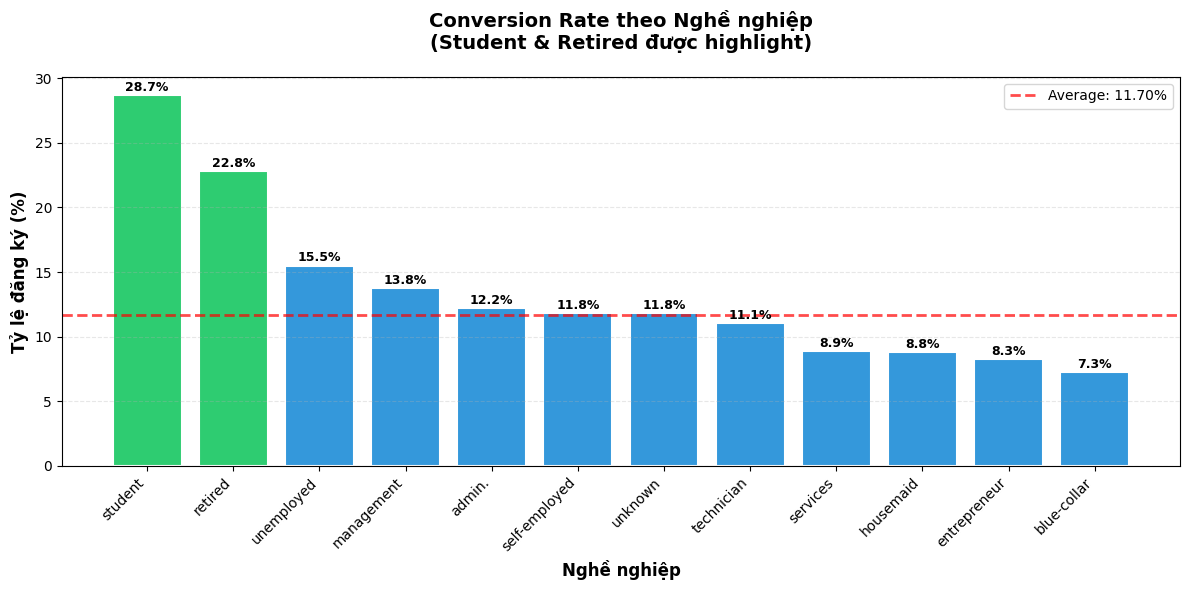


📋 SỐ LƯỢNG MẪU THEO NGHỀ NGHIỆP:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288


In [34]:
# ==========================================
# PHÂN TÍCH TỶ LỆ ĐĂNG KÝ THEO NGHỀ NGHIỆP
# ==========================================

# 1. Tính tỷ lệ đăng ký (conversion rate) theo job
job_conversion = df_full.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

# 2. Tính tỷ lệ trung bình toàn dataset
avg_rate = (df_full['y'] == 'yes').mean() * 100

# 3. In bảng thống kê
print("=" * 60)
print("TỶ LỆ ĐĂNG KÝ GỬI TIẾT KIỆM THEO NGHỀ NGHIỆP")
print("=" * 60)
print(f"{'Nghề nghiệp':<20} {'Tỷ lệ (%)':>10} {'So với TB':>12}")
print("-" * 60)

for job, rate in job_conversion.items():
    diff = rate - avg_rate
    sign = "+" if diff > 0 else ""
    marker = " 🟢" if diff > 0 else " 🔴"
    print(f"{job:<20} {rate:>9.2f}% {sign}{diff:>10.2f}%{marker}")

print("-" * 60)
print(f"{'TRUNG BÌNH':<20} {avg_rate:>9.2f}%")
print("=" * 60)

# 4. Vẽ biểu đồ Bar chart với đường trung bình
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if job in ['student', 'retired'] else '#3498db' 
          for job in job_conversion.index]

bars = plt.bar(job_conversion.index, job_conversion.values, 
               color=colors, edgecolor='white', linewidth=1.5)

# Thêm đường trung bình
plt.axhline(y=avg_rate, color='red', linestyle='--', linewidth=2, 
            label=f'Average: {avg_rate:.2f}%', alpha=0.7)

# Thêm giá trị lên đầu mỗi bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Trang trí biểu đồ
plt.xlabel('Nghề nghiệp', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ đăng ký (%)', fontsize=12, fontweight='bold')
plt.title('Conversion Rate theo Nghề nghiệp\n(Student & Retired được highlight)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()

# 5. Thống kê số lượng mẫu
print("\n📋 SỐ LƯỢNG MẪU THEO NGHỀ NGHIỆP:")
print(df_full['job'].value_counts().to_string())

Insight kinh doanh:

- Student: Mặc dù số lượng mẫu không lớn nhất, nhưng tỷ lệ chuyển đổi rất cao. Có thể do sinh viên nhạy bén với các sản phẩm tiết kiệm hoặc chiến dịch marketing nhắm đúng đối tượng này.
- Retired: Người về hưu có nhu cầu bảo toàn tài sản và thu nhập ổn định, nên sản phẩm gửi tiết kiệm rất phù hợp.
- Blue-collar: Nhóm này có tỷ lệ thấp nhất, có thể do thu nhập không ổn định hoặc ưu tiên chi tiêu khác. Cần chiến lược tiếp cận khác hoặc sản phẩm phù hợp hơn.


Kết quả chiến dịch trước có ảnh hưởng không?

In [38]:
# ==========================================
# TASK 2: PHÂN TÍCH POUTCOME (ĐÃ SỬA LỖI)
# ==========================================
print("=" * 60)
print("TASK 2: ẢNH HƯỞNG CỦA KẾT QUẢ CHIẾN DỊCH TRƯỚC (poutcome)")
print("=" * 60)

# 1. Tính conversion rate theo poutcome
poutcome_stats = df_full.groupby('poutcome')['y'].agg(
    total='count',
    yes=lambda x: (x == 'yes').sum(),
    conversion_rate=lambda x: (x == 'yes').mean() * 100
).sort_values('conversion_rate', ascending=False)

# 2. Tính trung bình toàn dataset
avg_rate = (df_full['y'] == 'yes').mean() * 100

# 3. In bảng thống kê (ĐÃ SỬA LỖI FORMAT)
print(f"\n{'poutcome':<15} {'Số lượng':>10} {'Đăng ký':>10} {'Conv. Rate':>12} {'So với TB':>12}")
print("-" * 60)

for idx, row in poutcome_stats.iterrows():
    diff = row['conversion_rate'] - avg_rate
    sign = "+" if diff > 0 else ""
    marker = " 🟢" if diff > 0 else " 🔴"
    highlight = " ⭐" if idx == 'success' else ""
    
    # ✅ FIX: Ép kiểu int() để tránh lỗi format 'd' với float
    print(f"{idx:<15} {int(row['total']):>10d} {int(row['yes']):>10d} "
          f"{row['conversion_rate']:>11.2f}% {sign}{diff:>10.2f}%{marker}{highlight}")

print("-" * 60)
print(f"{'TRUNG BÌNH':<15} {len(df_full):>10d} {(df_full['y']=='yes').sum():>10d} {avg_rate:>11.2f}%")
print("=" * 60)

TASK 2: ẢNH HƯỞNG CỦA KẾT QUẢ CHIẾN DỊCH TRƯỚC (poutcome)

poutcome          Số lượng    Đăng ký   Conv. Rate    So với TB
------------------------------------------------------------
success               1511        978       64.73% +     53.03% 🟢 ⭐
other                 1840        307       16.68% +      4.99% 🟢
failure               4901        618       12.61% +      0.91% 🟢
unknown              36959       3386        9.16%      -2.54% 🔴
------------------------------------------------------------
TRUNG BÌNH           45211       5289       11.70%


Gọi càng nhiều lần có tốt hơn không? 


TASK 3: ẢNH HƯỞNG CỦA SỐ LẦN GỌI (campaign)

  Campaign   Số lượng   Conv. Rate     Xu hướng
--------------------------------------------------
         1      17544       14.60%            —
         2      12505       11.20%       📉 Giảm
         3       5521       11.19%   ➡️ Ổn định
         4       3522        9.00%       📉 Giảm
         5       1764        7.88%       📉 Giảm
         6       1291        7.13%       📉 Giảm
         7        735        6.39%       📉 Giảm
         8        540        5.93%   ➡️ Ổn định
         9        327        6.42%   ➡️ Ổn định
        10        266        5.26%       📉 Giảm
        11        201        7.96%       📈 Tăng
        12        155        2.58%       📉 Giảm
        13        133        4.51%       📈 Tăng
        14         93        4.30%   ➡️ Ổn định
        15         84        4.76%   ➡️ Ổn định


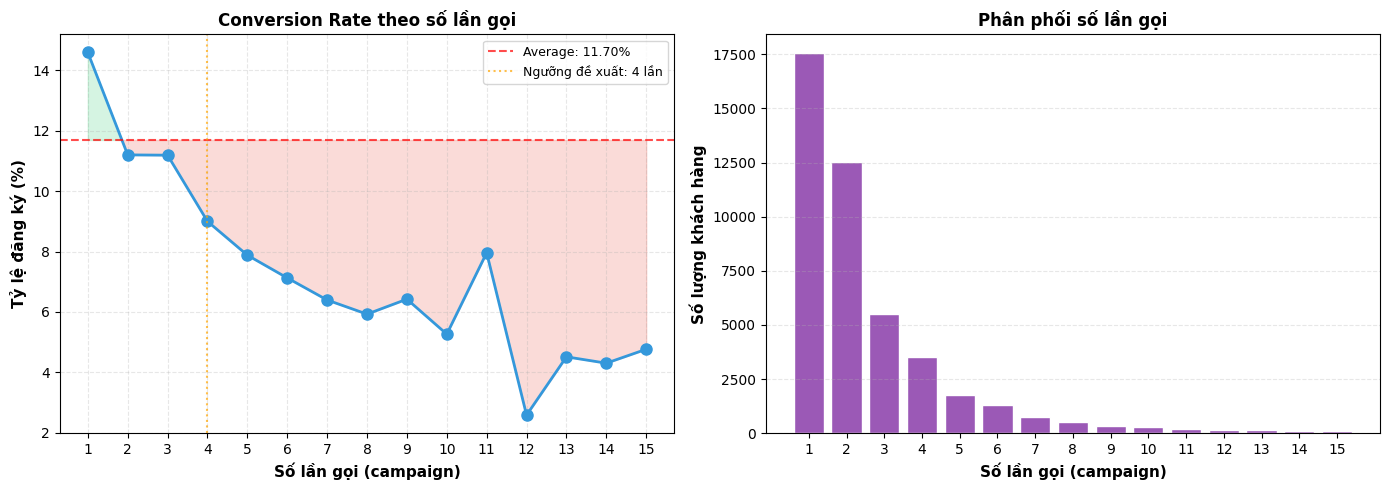


💡 INSIGHT & KHUYẾN NGHỊ:
📊 Conversion rate khi campaign ≤ 4: 12.53%
📉 Conversion rate khi campaign > 4: 6.41%

🎯 KHUYẾN NGHỊ: Giới hạn số lần gọi tối đa là 4 lần/khách.
   Gọi quá 4 lần không tăng conversion mà còn gây phản tác dụng,
   đồng thời lãng phí nguồn lực telesales.


In [39]:
# ==========================================
# TASK 3: PHÂN TÍCH SỐ LẦN GỌI (campaign)
# ==========================================
print("\n" + "=" * 60)
print("TASK 3: ẢNH HƯỞNG CỦA SỐ LẦN GỌI (campaign)")
print("=" * 60)

# 1. Tính conversion rate theo số lần gọi
# Giới hạn ở campaign <= 15 để tránh noise (số lượng mẫu quá ít ở giá trị cao)
df_campaign = df_full[df_full['campaign'] <= 15].copy()

campaign_stats = df_campaign.groupby('campaign')['y'].agg(
    total='count',
    conversion_rate=lambda x: (x == 'yes').mean() * 100
)

# 2. In bảng thống kê
print(f"\n{'Campaign':>10} {'Số lượng':>10} {'Conv. Rate':>12} {'Xu hướng':>12}")
print("-" * 50)

prev_rate = None
for idx, row in campaign_stats.iterrows():
    if prev_rate is None:
        trend = "—"
    else:
        diff = row['conversion_rate'] - prev_rate
        if diff > 0.5:
            trend = "📈 Tăng"
        elif diff < -0.5:
            trend = "📉 Giảm"
        else:
            trend = "➡️ Ổn định"
    print(f"{idx:>10} {int(row['total']):>10d} {row['conversion_rate']:>11.2f}% {trend:>12}")
    prev_rate = row['conversion_rate']

# 3. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Conversion rate
ax1.plot(campaign_stats.index, campaign_stats['conversion_rate'], 
         marker='o', linewidth=2, markersize=8, color='#3498db')
ax1.axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, 
            label=f'Average: {avg_rate:.2f}%')
ax1.fill_between(campaign_stats.index, campaign_stats['conversion_rate'], avg_rate,
                 where=(campaign_stats['conversion_rate'] >= avg_rate), 
                 color='#2ecc71', alpha=0.2, interpolate=True)
ax1.fill_between(campaign_stats.index, campaign_stats['conversion_rate'], avg_rate,
                 where=(campaign_stats['conversion_rate'] < avg_rate), 
                 color='#e74c3c', alpha=0.2, interpolate=True)

# Highlight ngưỡng
threshold = 4
ax1.axvline(x=threshold, color='orange', linestyle=':', alpha=0.7, 
            label=f'Ngưỡng đề xuất: {threshold} lần')
ax1.set_xlabel('Số lần gọi (campaign)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tỷ lệ đăng ký (%)', fontsize=11, fontweight='bold')
ax1.set_title('Conversion Rate theo số lần gọi', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xticks(campaign_stats.index)

# Biểu đồ 2: Phân phối số lượng cuộc gọi
ax2.bar(campaign_stats.index, campaign_stats['total'], color='#9b59b6', edgecolor='white')
ax2.set_xlabel('Số lần gọi (campaign)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng khách hàng', fontsize=11, fontweight='bold')
ax2.set_title('Phân phối số lần gọi', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_xticks(campaign_stats.index)

plt.tight_layout()
plt.show()

# 4. Tìm ngưỡng tối ưu
print("\n" + "=" * 60)
print("💡 INSIGHT & KHUYẾN NGHỊ:")
print("=" * 60)

# Tính conversion rate trung bình cho campaign <= threshold và > threshold
rate_under = df_full[df_full['campaign'] <= threshold]['y'].apply(lambda x: x=='yes').mean() * 100
rate_over = df_full[df_full['campaign'] > threshold]['y'].apply(lambda x: x=='yes').mean() * 100

print(f"📊 Conversion rate khi campaign ≤ {threshold}: {rate_under:.2f}%")
print(f"📉 Conversion rate khi campaign > {threshold}: {rate_over:.2f}%")
print(f"\n🎯 KHUYẾN NGHỊ: Giới hạn số lần gọi tối đa là {threshold} lần/khách.")
print(f"   Gọi quá {threshold} lần không tăng conversion mà còn gây phản tác dụng,")
print(f"   đồng thời lãng phí nguồn lực telesales.")

⚠️  Cảnh báo: Chưa tìm thấy biến is_prev_contacted/prev_success.
   Đang tự động tạo biến từ poutcome để phân tích...
1. PHÂN TÍCH MARGINAL GAIN THEO PHÂN KHÚC MỚI

📊 MARGINAL GAIN THEO IS_PREV_CONTACTED:
Khách mới       (is_prev_contacted=0): Tối đa 1 lần gọi
Khách cũ        (is_prev_contacted=1): Tối đa 6 lần gọi

📊 MARGINAL GAIN THEO PREV_SUCCESS:
Chưa thành công      (prev_success=0): Tối đa 1 lần gọi
Đã thành công        (prev_success=1): Tối đa 4 lần gọi


/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3343199860.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  contact_marginal = df_campaign.groupby('is_prev_contacted').apply(calc_marginal_gain)
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3343199860.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  success_marginal = df_campaign.groupby('prev_success').apply(calc_marginal_g

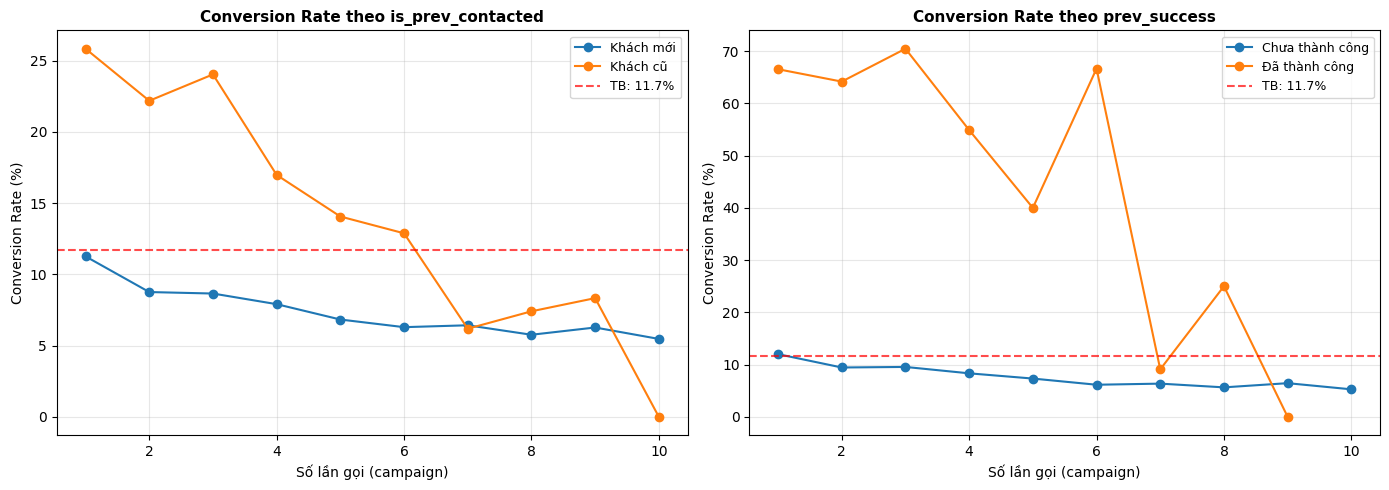

In [14]:
# ==========================================
# SMART CALLBACK STRATEGY (PHIÊN BẢN FEATURE ENGINEERING MỚI)
# Sử dụng: is_prev_contacted, prev_success thay cho poutcome
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df_fe là dataframe đã được feature engineering
# Nếu bạn dùng df_full, hãy đảm bảo đã tạo 2 biến mới trước khi chạy
if 'is_prev_contacted' not in df_full.columns or 'prev_success' not in df_full.columns:
    print("⚠️  Cảnh báo: Chưa tìm thấy biến is_prev_contacted/prev_success.")
    print("   Đang tự động tạo biến từ poutcome để phân tích...")
    df = df_full.copy()
    df['is_prev_contacted'] = (df['poutcome'] != 'unknown').astype(int)
    df['prev_success'] = (df['poutcome'] == 'success').astype(int)
else:
    df = df_full.copy()

df['converted'] = (df['y'] == 'yes').astype(int)
avg_rate = df['converted'].mean() * 100

print("=" * 70)
print("1. PHÂN TÍCH MARGINAL GAIN THEO PHÂN KHÚC MỚI")
print("=" * 70)

# Giới hạn campaign để tránh noise
df_campaign = df[df['campaign'] <= 10].copy()

# Hàm tính marginal gain
def calc_marginal_gain(group):
    stats = group.groupby('campaign')['converted'].agg(['count', 'mean']).sort_index()
    stats['conv_rate'] = stats['mean'] * 100
    stats['marginal_gain'] = stats['conv_rate'].diff()
    return stats

# --- Phân tích theo is_prev_contacted ---
print("\n📊 MARGINAL GAIN THEO IS_PREV_CONTACTED:")
contact_marginal = df_campaign.groupby('is_prev_contacted').apply(calc_marginal_gain)

for is_contacted in [0, 1]:
    if is_contacted in contact_marginal.index.get_level_values(0):
        stats = contact_marginal.loc[is_contacted]
        valid = stats[stats['count'] >= 100]
        if len(valid) > 0:
            above_avg = valid[valid['conv_rate'] > avg_rate]
            optimal = above_avg.index.max() if len(above_avg) > 0 else 1
            label = "Khách cũ" if is_contacted == 1 else "Khách mới"
            print(f"{label:<15} (is_prev_contacted={is_contacted}): Tối đa {int(optimal)} lần gọi")

# --- Phân tích theo prev_success ---
print("\n📊 MARGINAL GAIN THEO PREV_SUCCESS:")
success_marginal = df_campaign.groupby('prev_success').apply(calc_marginal_gain)

for prev_succ in [0, 1]:
    if prev_succ in success_marginal.index.get_level_values(0):
        stats = success_marginal.loc[prev_succ]
        valid = stats[stats['count'] >= 50]
        if len(valid) > 0:
            above_avg = valid[valid['conv_rate'] > avg_rate]
            optimal = above_avg.index.max() if len(above_avg) > 0 else 1
            label = "Đã thành công" if prev_succ == 1 else "Chưa thành công"
            print(f"{label:<20} (prev_success={prev_succ}): Tối đa {int(optimal)} lần gọi")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: is_prev_contacted
for is_contacted in [0, 1]:
    if is_contacted in contact_marginal.index.get_level_values(0):
        stats = contact_marginal.loc[is_contacted]
        label = "Khách cũ" if is_contacted == 1 else "Khách mới"
        axes[0].plot(stats.index, stats['conv_rate'], marker='o', label=label)
axes[0].axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, label=f'TB: {avg_rate:.1f}%')
axes[0].set_xlabel('Số lần gọi (campaign)', fontsize=10)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=10)
axes[0].set_title('Conversion Rate theo is_prev_contacted', fontsize=11, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(alpha=0.3)

# Biểu đồ 2: prev_success
for prev_succ in [0, 1]:
    if prev_succ in success_marginal.index.get_level_values(0):
        stats = success_marginal.loc[prev_succ]
        label = "Đã thành công" if prev_succ == 1 else "Chưa thành công"
        axes[1].plot(stats.index, stats['conv_rate'], marker='o', label=label)
axes[1].axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, label=f'TB: {avg_rate:.1f}%')
axes[1].set_xlabel('Số lần gọi (campaign)', fontsize=10)
axes[1].set_ylabel('Conversion Rate (%)', fontsize=10)
axes[1].set_title('Conversion Rate theo prev_success', fontsize=11, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


2. CHIẾN LƯỢC GỌI LẠI CHO NHÓM PREV_SUCCESS=0

📋 CONVERSION RATE THEO PDAYS CHO NHÓM PREV_SUCCESS=0:
Nhóm pdays             Số lượng   Conv. Rate    So với TB
-------------------------------------------------------
<30 ngày                    158        9.49%      -2.20% 🔴
30-60 ngày                   84       32.14% +     20.44% 🟢
60-90 ngày                  258       29.07% +     17.37% 🟢
90-180 ngày                1864       15.50% +      3.81% 🟢
180-300 ngày               2060       12.72% +      1.02% 🟢
>300 ngày                  2317       11.09%      -0.61% 🔴


/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3410752198.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pdays_stats = df_prev_fail.groupby('pdays_group')['converted'].agg(
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3410752198.py:60: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


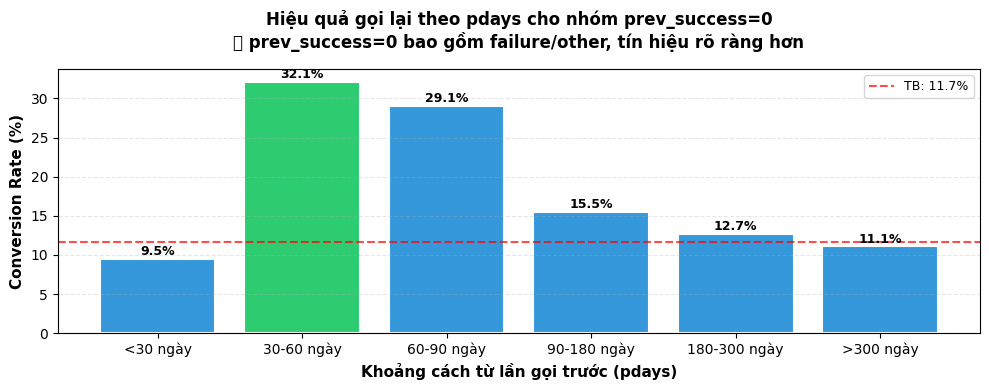


💡 KHUYẾN NGHỊ CHO PREV_SUCCESS=0:
✅ Nên gọi lại sau khoảng 30-60 ngày để đạt conversion rate tối ưu (32.14%).
   Tránh gọi lại quá sớm (<30 ngày) vì conversion rate thấp hơn trung bình.
   Nhóm này khó chốt hơn, cần kiên nhẫn và timing chính xác.


In [16]:
print("\n" + "=" * 70)
print("2. CHIẾN LƯỢC GỌI LẠI CHO NHÓM PREV_SUCCESS=0")
print("=" * 70)

# Lọc nhóm prev_success=0 và có lịch sử gọi (pdays != -1)
# Đây chính là nhóm khách cũ nhưng chưa từng thành công
df_prev_fail = df[(df['prev_success'] == 0) & 
                  (df['is_prev_contacted'] == 1) & 
                  (df['pdays'] != -1)].copy()

if len(df_prev_fail) > 0:
    # Phân tích conversion rate theo pdays
    df_prev_fail['pdays_group'] = pd.cut(df_prev_fail['pdays'], 
                                         bins=[0, 30, 60, 90, 180, 300, 1000], 
                                         labels=['<30 ngày', '30-60 ngày', '60-90 ngày', 
                                                 '90-180 ngày', '180-300 ngày', '>300 ngày'])
    
    pdays_stats = df_prev_fail.groupby('pdays_group')['converted'].agg(
        count='count',
        conv_rate=lambda x: x.mean() * 100
    )
    
    print("\n📋 CONVERSION RATE THEO PDAYS CHO NHÓM PREV_SUCCESS=0:")
    print(f"{'Nhóm pdays':<20} {'Số lượng':>10} {'Conv. Rate':>12} {'So với TB':>12}")
    print("-" * 55)
    
    best_pdays = None
    max_rate = 0
    
    for idx, row in pdays_stats.iterrows():
        diff = row['conv_rate'] - avg_rate
        sign = "+" if diff > 0 else ""
        marker = " 🟢" if diff > 0 else " 🔴"
        
        if row['conv_rate'] > max_rate and row['count'] >= 50:
            max_rate = row['conv_rate']
            best_pdays = idx
            
        print(f"{str(idx):<20} {int(row['count']):>10d} {row['conv_rate']:>11.2f}% {sign}{diff:>10.2f}%{marker}")
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 4))
    colors = ['#2ecc71' if idx == best_pdays else '#3498db' for idx in pdays_stats.index]
    bars = plt.bar(pdays_stats.index.astype(str), pdays_stats['conv_rate'], 
                   color=colors, edgecolor='white', linewidth=1.5)
    
    plt.axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, label=f'TB: {avg_rate:.1f}%')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.xlabel('Khoảng cách từ lần gọi trước (pdays)', fontsize=11, fontweight='bold')
    plt.ylabel('Conversion Rate (%)', fontsize=11, fontweight='bold')
    plt.title('Hiệu quả gọi lại theo pdays cho nhóm prev_success=0\n💡 prev_success=0 bao gồm failure/other, tín hiệu rõ ràng hơn', 
              fontsize=12, fontweight='bold', pad=15)
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 KHUYẾN NGHỊ CHO PREV_SUCCESS=0:")
    if best_pdays:
        print(f"✅ Nên gọi lại sau khoảng {best_pdays} để đạt conversion rate tối ưu ({max_rate:.2f}%).")
        print(f"   Tránh gọi lại quá sớm (<30 ngày) vì conversion rate thấp hơn trung bình.")
        print(f"   Nhóm này khó chốt hơn, cần kiên nhẫn và timing chính xác.")
    else:
        print("⚠️  Không tìm thấy khoảng pdays nào vượt trội. Cân nhắc loại bỏ nhóm này hoặc test A/B.")
else:
    print("⚠️  Không có dữ liệu cho nhóm prev_success=0 với pdays != -1.")


3. TƯƠNG TÁC PDAYS × PREV_SUCCESS


/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3741973615.py:25: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3741973615.py:25: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


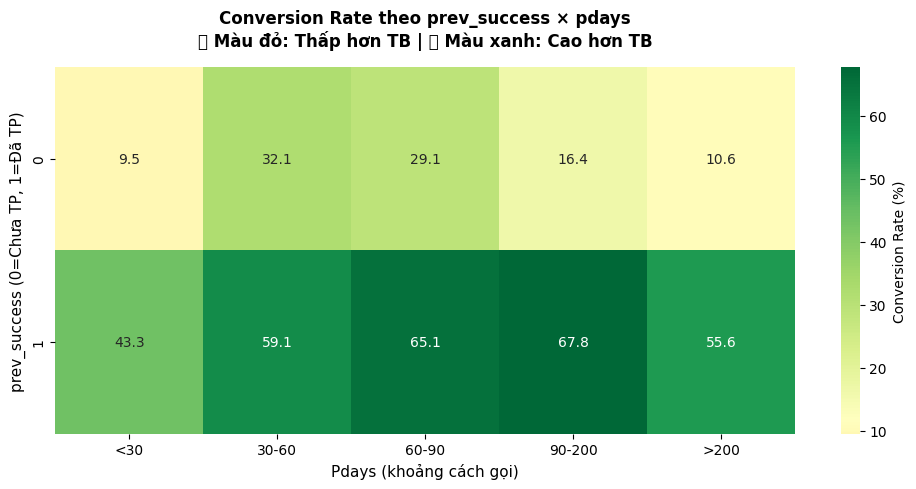


📊 PHÂN TÍCH TƯƠNG TÁC:
✅ Nhóm prev_success=1: Conv rate cao nhất ở pdays=90-200 (67.77%).
   → Nhóm này rất nhạy, có thể gọi lại sớm hơn mà vẫn hiệu quả.
⚠️  Nhóm prev_success=0: Conv rate cao nhất ở pdays=30-60 (32.14%).
   → Cần khoảng cách gọi xa hơn để tránh làm phiền và tăng hiệu quả.

💡 KHUYẾN NGHỊ:
   • prev_success=1: Gọi lại nhanh (pdays ngắn), tối đa 2-3 lần.
   • prev_success=0: Gọi lại chậm (pdays dài), tối đa 2 lần, tránh spam.


In [17]:
print("\n" + "=" * 70)
print("3. TƯƠNG TÁC PDAYS × PREV_SUCCESS")
print("=" * 70)

# Lọc khách hàng có lịch sử gọi
df_prev = df[(df['pdays'] != -1) & (df['previous'] > 0)].copy()

if len(df_prev) > 0:
    # Tạo nhóm cho pdays
    df_prev['pdays_bin'] = pd.cut(df_prev['pdays'], bins=[0, 30, 60, 90, 200, 1000], 
                                  labels=['<30', '30-60', '60-90', '90-200', '>200'])
    
    # Tính conversion rate theo tương tác prev_success × pdays
    interaction_stats = pd.crosstab(df_prev['prev_success'], df_prev['pdays_bin'], 
                                    values=df_prev['converted'], aggfunc='mean') * 100
    
    # Vẽ heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(interaction_stats, annot=True, fmt='.1f', cmap='RdYlGn', 
                center=avg_rate, cbar_kws={'label': 'Conversion Rate (%)'})
    plt.title('Conversion Rate theo prev_success × pdays\n🔴 Màu đỏ: Thấp hơn TB | 🟢 Màu xanh: Cao hơn TB', 
              fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Pdays (khoảng cách gọi)', fontsize=11)
    plt.ylabel('prev_success (0=Chưa TP, 1=Đã TP)', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Phân tích insight
    print("\n📊 PHÂN TÍCH TƯƠNG TÁC:")
    
    # Nhóm prev_success=1
    if 1 in interaction_stats.index:
        success_stats = interaction_stats.loc[1]
        best_pdays_success = success_stats.idxmax()
        max_rate_success = success_stats.max()
        print(f"✅ Nhóm prev_success=1: Conv rate cao nhất ở pdays={best_pdays_success} ({max_rate_success:.2f}%).")
        print(f"   → Nhóm này rất nhạy, có thể gọi lại sớm hơn mà vẫn hiệu quả.")
    
    # Nhóm prev_success=0
    if 0 in interaction_stats.index:
        fail_stats = interaction_stats.loc[0]
        best_pdays_fail = fail_stats.idxmax()
        max_rate_fail = fail_stats.max()
        print(f"⚠️  Nhóm prev_success=0: Conv rate cao nhất ở pdays={best_pdays_fail} ({max_rate_fail:.2f}%).")
        print(f"   → Cần khoảng cách gọi xa hơn để tránh làm phiền và tăng hiệu quả.")
    
    print(f"\n💡 KHUYẾN NGHỊ:")
    print("   • prev_success=1: Gọi lại nhanh (pdays ngắn), tối đa 2-3 lần.")
    print("   • prev_success=0: Gọi lại chậm (pdays dài), tối đa 2 lần, tránh spam.")
else:
    print("⚠️  Không đủ dữ liệu để phân tích tương tác.")

In [18]:
print("\n" + "=" * 70)
print("4. ĐỀ XUẤT CHIẾN LƯỢC GỌI LẠI ĐỘNG (SMART CALLBACK STRATEGY)")
print("   Dựa trên is_prev_contacted và prev_success")
print("=" * 70)

print("\n📅 QUY TẮC GỌI THEO PHÂN KHÚC MỚI:")
print("-" * 70)

# Tổng hợp từ các phân tích trên
rules = {
    'is_prev_contacted=0': {
        'desc': 'Khách mới (chưa từng gọi)',
        'max_calls': 4,
        'min_pdays': 'N/A',
        'note': 'Áp dụng quy tắc theo job/age, giới hạn 4 lần để tránh spam.'
    },
    'is_prev_contacted=1 & prev_success=1': {
        'desc': 'Khách cũ đã thành công',
        'max_calls': 2,
        'min_pdays': 15,
        'note': 'Nhóm vàng! Gọi lại ngay, tối đa 2 lần, cách nhau 15-30 ngày.'
    },
    'is_prev_contacted=1 & prev_success=0': {
        'desc': 'Khách cũ chưa thành công',
        'max_calls': 2,
        'min_pdays': 60,
        'note': 'Chỉ gọi lại nếu pdays ≥ 60 ngày. Tránh gọi dồn, cân nhắc loại bỏ nếu previous ≥ 3.'
    }
}

for key, rule in rules.items():
    print(f"👤 {key:<35} : {rule['desc']}")
    print(f"   📞 Gọi tối đa {rule['max_calls']} lần, cách nhau ít nhất {rule['min_pdays']} ngày")
    print(f"   💬 {rule['note']}\n")

print("\n🎯 LỢI ÍCH CỦA CÁCH TIẾP CẬN MỚI:")
print("   • Tách bạch rõ ràng 3 nhóm khách hàng với chiến lược tối ưu riêng.")
print("   • prev_success=1 được ưu tiên tuyệt đối → Tăng ROI nhanh.")
print("   • prev_success=0 được kiểm soát chặt → Giảm chi phí lãng phí và churn.")
print("   • Mô hình học pattern rõ ràng hơn, giảm nhiễu so với poutcome gốc.")
print("   • Dễ dàng tích hợp vào hệ thống scoring và automation.")


4. ĐỀ XUẤT CHIẾN LƯỢC GỌI LẠI ĐỘNG (SMART CALLBACK STRATEGY)
   Dựa trên is_prev_contacted và prev_success

📅 QUY TẮC GỌI THEO PHÂN KHÚC MỚI:
----------------------------------------------------------------------
👤 is_prev_contacted=0                 : Khách mới (chưa từng gọi)
   📞 Gọi tối đa 4 lần, cách nhau ít nhất N/A ngày
   💬 Áp dụng quy tắc theo job/age, giới hạn 4 lần để tránh spam.

👤 is_prev_contacted=1 & prev_success=1 : Khách cũ đã thành công
   📞 Gọi tối đa 2 lần, cách nhau ít nhất 15 ngày
   💬 Nhóm vàng! Gọi lại ngay, tối đa 2 lần, cách nhau 15-30 ngày.

👤 is_prev_contacted=1 & prev_success=0 : Khách cũ chưa thành công
   📞 Gọi tối đa 2 lần, cách nhau ít nhất 60 ngày
   💬 Chỉ gọi lại nếu pdays ≥ 60 ngày. Tránh gọi dồn, cân nhắc loại bỏ nếu previous ≥ 3.


🎯 LỢI ÍCH CỦA CÁCH TIẾP CẬN MỚI:
   • Tách bạch rõ ràng 3 nhóm khách hàng với chiến lược tối ưu riêng.
   • prev_success=1 được ưu tiên tuyệt đối → Tăng ROI nhanh.
   • prev_success=0 được kiểm soát chặt → Giảm chi phí 

Tháng nào chiến dịch hiệu quả hơn?


TASK 4: HIỆU QUẢ CHIẾN DỊCH THEO THÁNG (month)

Tháng      Số lượng    Đăng ký   Conv. Rate    So với TB
------------------------------------------------------------
jan            1403        142       10.12%      -1.58% 🔴
feb            2649        441       16.65% +      4.95% 🟢 ⭐
mar             477        248       51.99% +     40.29% 🟢 ⭐
apr            2932        577       19.68% +      7.98% 🟢 ⭐
may           13766        925        6.72%      -4.98% 🔴
jun            5341        546       10.22%      -1.48% 🔴
jul            6895        627        9.09%      -2.60% 🔴
aug            6247        688       11.01%      -0.69% 🔴
sep             579        269       46.46% +     34.76% 🟢 ⭐
oct             738        323       43.77% +     32.07% 🟢 ⭐
nov            3970        403       10.15%      -1.55% 🔴
dec             214        100       46.73% +     35.03% 🟢 ⭐
------------------------------------------------------------
TRUNG BÌNH      45211       5289       11.70%


/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_69109/3914070328.py:57: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


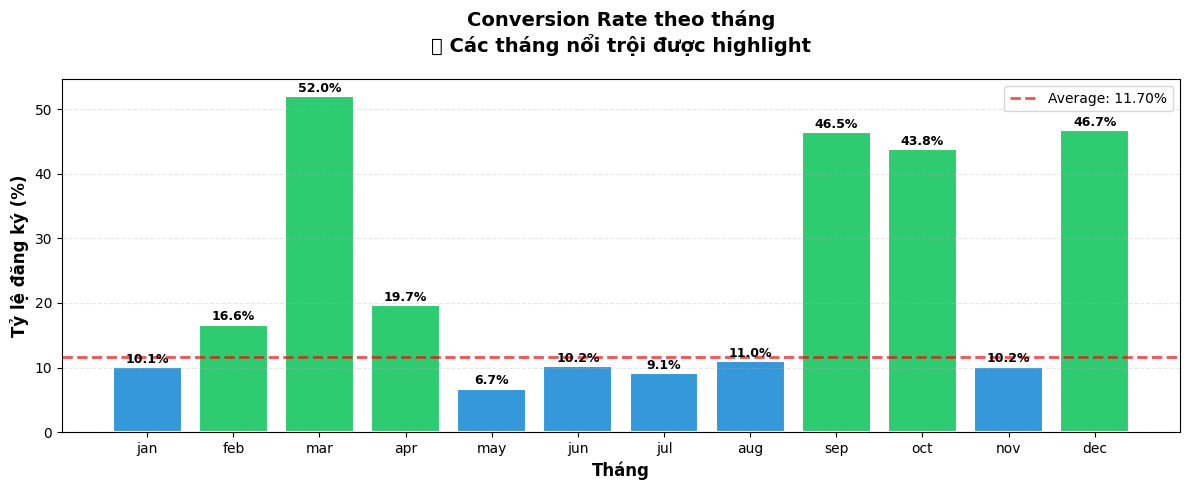


💡 INSIGHT SEASONALITY:
✅ Các tháng có conversion rate vượt trội: FEB, MAR, APR, SEP, OCT, DEC
   (cao hơn trung bình ít nhất 2%)

🎯 KHUYẾN NGHỊ: Tập trung ngân sách và nguồn lực telesales
   vào các tháng này để tối ưu hiệu quả chiến dịch.


In [45]:
# ==========================================
# TASK 4: PHÂN TÍCH THEO THÁNG (month)
# ==========================================
print("\n" + "=" * 60)
print("TASK 4: HIỆU QUẢ CHIẾN DỊCH THEO THÁNG (month)")
print("=" * 60)

# 1. Tính conversion rate theo tháng
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_stats = df_full.groupby('month')['y'].agg(
    total='count',
    yes=lambda x: (x == 'yes').sum(),
    conversion_rate=lambda x: (x == 'yes').mean() * 100
).reindex(month_order)

# 2. In bảng thống kê
print(f"\n{'Tháng':<8} {'Số lượng':>10} {'Đăng ký':>10} {'Conv. Rate':>12} {'So với TB':>12}")
print("-" * 60)

best_months = []
for idx, row in month_stats.iterrows():
    diff = row['conversion_rate'] - avg_rate
    sign = "+" if diff > 0 else ""
    marker = " 🟢" if diff > 0 else " 🔴"
    if diff > 2:  # Tháng nổi trội
        best_months.append(idx)
        marker += " ⭐"
    print(f"{idx:<8} {int(row['total']):>10d} {int(row['yes']):>10d} "
          f"{row['conversion_rate']:>11.2f}% {sign}{diff:>10.2f}%{marker}")

print("-" * 60)
print(f"{'TRUNG BÌNH':<8} {len(df_full):>10d} {(df_full['y']=='yes').sum():>10d} {avg_rate:>11.2f}%")

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if idx in best_months else '#3498db' for idx in month_stats.index]

bars = plt.bar(month_stats.index, month_stats['conversion_rate'], 
               color=colors, edgecolor='white', linewidth=1.5)

plt.axhline(y=avg_rate, color='red', linestyle='--', linewidth=2, 
            label=f'Average: {avg_rate:.2f}%', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Tháng', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ đăng ký (%)', fontsize=12, fontweight='bold')
plt.title('Conversion Rate theo tháng\n⭐ Các tháng nổi trội được highlight', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 4. INSIGHT
print("\n" + "=" * 60)
print("💡 INSIGHT SEASONALITY:")
print("=" * 60)
if best_months:
    print(f"✅ Các tháng có conversion rate vượt trội: {', '.join(best_months).upper()}")
    print(f"   (cao hơn trung bình ít nhất 2%)")
    print(f"\n🎯 KHUYẾN NGHỊ: Tập trung ngân sách và nguồn lực telesales")
    print(f"   vào các tháng này để tối ưu hiệu quả chiến dịch.")
else:
    print("⚠️ Không có tháng nào vượt trội rõ rệt so với trung bình.")

1. TỔNG QUAN: VOLUME vs CONVERSION RATE THEO THÁNG
Tháng    Volume   % Volume     Conv  Conv Rate  So với TB Đánh giá       
----------------------------------------------------------------------
jan        1403       3.0%      142     10.00%     -1.58% ➖ Trung bình
feb        2649       5.0%      441     16.00% +     4.95% 🟢 Cao điểm
mar         477       1.0%      248     51.00% +    40.29% 🟢 Cao điểm
apr        2932       6.0%      577     19.00% +     7.98% 🟢 Cao điểm
may       13766      30.0%      925      6.00%     -4.98% 🔴 Thấp điểm
jun        5341      11.0%      546     10.00%     -1.48% ➖ Trung bình
jul        6895      15.0%      627      9.00%     -2.60% 🔴 Thấp điểm
aug        6247      13.0%      688     11.00%     -0.69% ➖ Trung bình
sep         579       1.0%      269     46.00% +    34.76% 🟢 Cao điểm
oct         738       1.0%      323     43.00% +    32.07% 🟢 Cao điểm
nov        3970       8.0%      403     10.00%     -1.55% ➖ Trung bình
dec         214       0.0%    

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/3272429077.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_stats = df.groupby('month').agg(


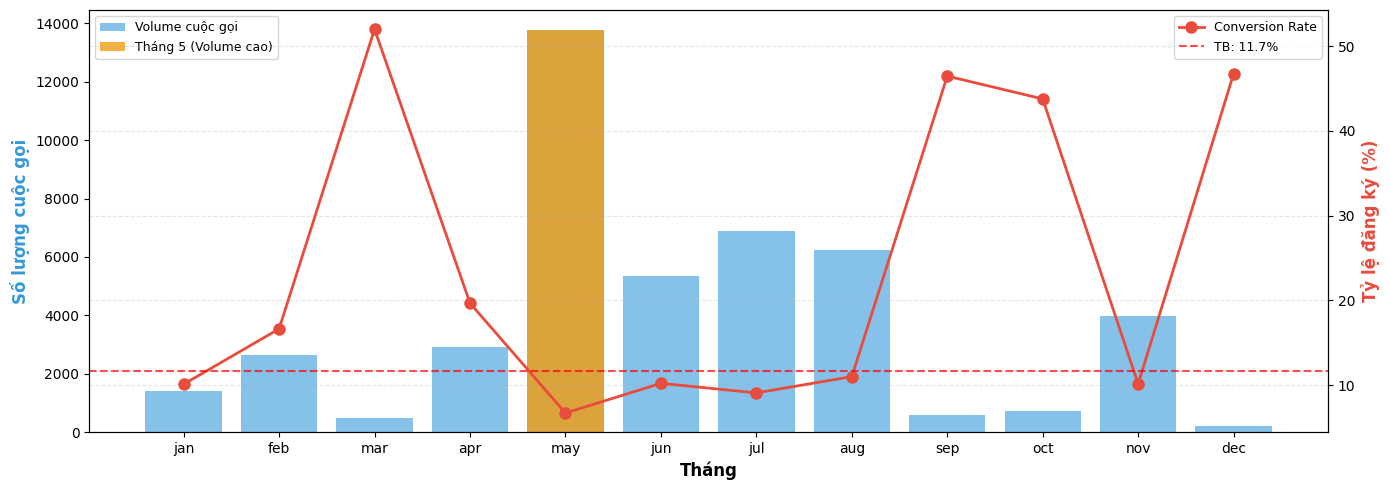

In [7]:
# ==========================================
# PHÂN TÍCH SEASONALITY & TIMING OPTIMIZATION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Giả sử df_full là dataframe gốc đã load
# Nếu đã có df_fe từ feature engineering, có thể dùng df_fe (nhưng cần giữ lại month, job, contact)
df = df_full.copy()

# Chuẩn bị thứ tự tháng
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Chuyển month sang categorical có thứ tự
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Tính conversion rate
df['converted'] = (df['y'] == 'yes').astype(int)
avg_rate = df['converted'].mean() * 100

print("=" * 70)
print("1. TỔNG QUAN: VOLUME vs CONVERSION RATE THEO THÁNG")
print("=" * 70)

# Thống kê theo tháng
month_stats = df.groupby('month').agg(
    total_calls=('converted', 'count'),
    conversions=('converted', 'sum'),
    conv_rate=('converted', 'mean')
).assign(
    conv_rate_pct=lambda x: x['conv_rate'] * 100,
    share_of_volume=lambda x: x['total_calls'] / x['total_calls'].sum() * 100
)

# In bảng
print(f"{'Tháng':<6} {'Volume':>8} {'% Volume':>10} {'Conv':>8} {'Conv Rate':>10} {'So với TB':>10} {'Đánh giá':<15}")
print("-" * 70)
for m in month_order:
    row = month_stats.loc[m]
    diff = row['conv_rate_pct'] - avg_rate
    sign = "+" if diff > 0 else ""
    
    # Phân loại hiệu quả
    if row['conv_rate_pct'] > avg_rate + 2:
        rating = "🟢 Cao điểm"
    elif row['conv_rate_pct'] < avg_rate - 2:
        rating = "🔴 Thấp điểm"
    else:
        rating = "➖ Trung bình"
        
    print(f"{m:<6} {int(row['total_calls']):>8d} {int(row['share_of_volume']):>9.1f}% "
          f"{int(row['conversions']):>8d} {int(row['conv_rate_pct']):>9.2f}% {sign}{diff:>9.2f}% {rating}")

print("-" * 70)
print(f"{'TỔNG':<6} {month_stats['total_calls'].sum():>8d} {'100.0%':>10} "
      f"{month_stats['conversions'].sum():>8d} {avg_rate:>9.2f}%")

# Vẽ biểu đồ Volume vs Conversion
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bars = ax1.bar(month_stats.index, month_stats['total_calls'], 
               color='#3498db', alpha=0.6, label='Volume cuộc gọi')
line = ax2.plot(month_stats.index, month_stats['conv_rate_pct'], 
                color='#e74c3c', marker='o', linewidth=2, markersize=8, label='Conversion Rate')

# Đường trung bình
ax2.axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, label=f'TB: {avg_rate:.1f}%')

# Highlight tháng 5
if 'may' in month_stats.index:
    may_idx = list(month_stats.index).index('may')
    ax1.bar(may_idx, month_stats.loc['may', 'total_calls'], 
            color='#f39c12', alpha=0.8, label='Tháng 5 (Volume cao)')

ax1.set_xlabel('Tháng', fontsize=12, fontweight='bold')
ax1.set_ylabel('Số lượng cuộc gọi', fontsize=12, fontweight='bold', color='#3498db')
ax2.set_ylabel('Tỷ lệ đăng ký (%)', fontsize=12, fontweight='bold', color='#e74c3c')

ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Volume ở đây là số cuộc gọi trong tháng đó
- Đồ thị cho thấy rằng ở mar, sep, oct, dù tỉ lệ conversion rate cao nhưng số lượng cuộc gọi lại thấp hơn trung bình -> Đẩy mạnh chiến dịch ở những tháng này hơn, điều ngược lại xảy ra ở tháng may, jun, jul, aug, gây hậu quả cao.
- Ở thàng 5, volume cao nhất nhưng tỉ lệ conversation rate lại thấp nhất -> Nguyên nhân do đâu ? 



2. PHÂN TÍCH TƯƠNG TÁC: MONTH vs JOB & CONTACT


/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/1438806295.py:16: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/1438806295.py:16: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vqd/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


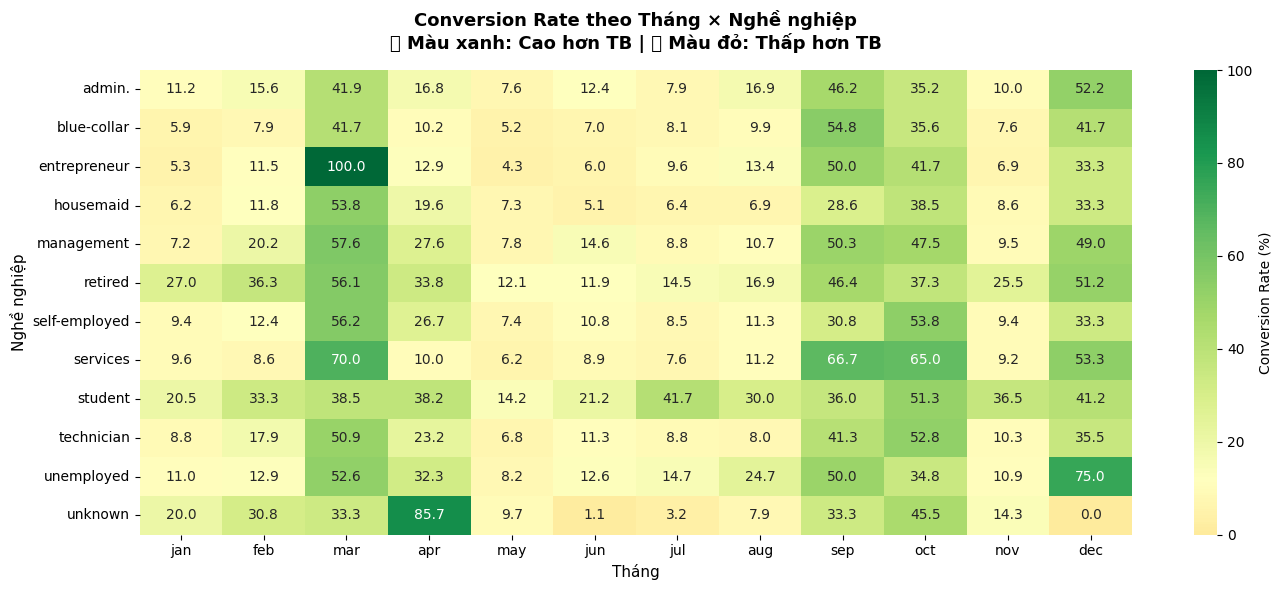

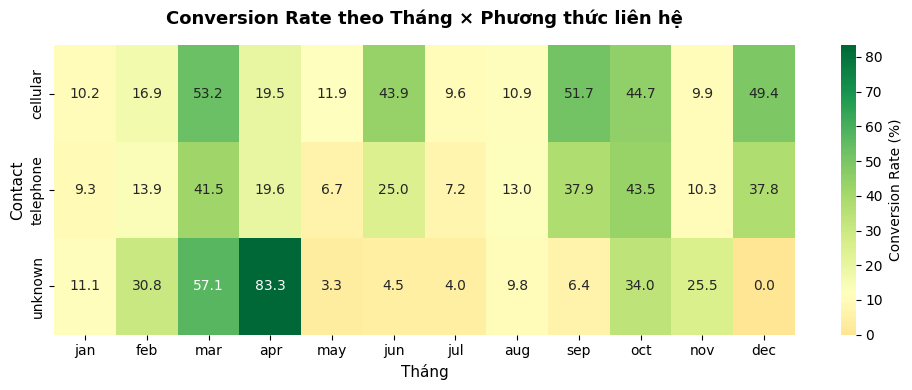

In [9]:
print("\n" + "=" * 70)
print("2. PHÂN TÍCH TƯƠNG TÁC: MONTH vs JOB & CONTACT")
print("=" * 70)

# Heatmap: Month vs Job
pivot_job = pd.crosstab(df['month'], df['job'], values=df['converted'], 
                        aggfunc='mean').reindex(month_order) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_job.T, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=avg_rate, cbar_kws={'label': 'Conversion Rate (%)'})
plt.title('Conversion Rate theo Tháng × Nghề nghiệp\n🟢 Màu xanh: Cao hơn TB | 🔴 Màu đỏ: Thấp hơn TB', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=11)
plt.ylabel('Nghề nghiệp', fontsize=11)
plt.tight_layout()
plt.show()

# Heatmap: Month vs Contact
pivot_contact = pd.crosstab(df['month'], df['contact'], values=df['converted'], 
                            aggfunc='mean').reindex(month_order) * 100

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_contact.T, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=avg_rate, cbar_kws={'label': 'Conversion Rate (%)'})
plt.title('Conversion Rate theo Tháng × Phương thức liên hệ', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=11)
plt.ylabel('Contact', fontsize=11)
plt.tight_layout()
plt.show()



In [11]:
print("\n" + "=" * 70)
print("3. KIỂM TRA: CHẤT LƯỢNG KHÁCH HÀNG vs HIỆU QUẢ THỰC THI")
print("=" * 70)

# Chất lượng khách hàng: Balance, Age, Education
quality_metrics = df.groupby('month').agg(
    avg_balance=('balance', 'mean'),
    median_balance=('balance', 'median'),
    avg_age=('age', 'mean'),
    pct_tertiary=('education', lambda x: (x == 'tertiary').mean() * 100),
    pct_management=('job', lambda x: (x == 'management').mean() * 100)
).reindex(month_order)

print("\n📋 CHẤT LƯỢNG KHÁCH HÀNG THEO THÁNG:")
print(quality_metrics.round(2).to_string())

# Kiểm tra correlation giữa quality và conversion
corr_balance = np.corrcoef(month_stats['conv_rate_pct'], quality_metrics['avg_balance'])[0, 1]
corr_tertiary = np.corrcoef(month_stats['conv_rate_pct'], quality_metrics['pct_tertiary'])[0, 1]

print(f"\n🔗 Correlation giữa Conversion Rate và:")
print(f"   - Average Balance: {corr_balance:.3f}")
print(f"   - % Tertiary Education: {corr_tertiary:.3f}")

if abs(corr_balance) < 0.3 and abs(corr_tertiary) < 0.3:
    print("✅ KẾT LUẬN: Chất lượng khách hàng KHÔNG phải là yếu tố chính giải thích")
    print("   sự khác biệt conversion rate giữa các tháng. Nguyên nhân có thể do:")
    print("   - Timing chiến dịch (mùa vụ, yếu tố ngoại cảnh)")
    print("   - Hiệu quả thực thi (số lần gọi, phương thức contact)")
else:
    print("⚠️  Chất lượng khách hàng có ảnh hưởng đến conversion rate theo tháng.")

# Hiệu quả thực thi: Campaign, Previous Success
execution_metrics = df.groupby('month').agg(
    avg_campaign=('campaign', 'mean'),
    pct_prev_success=('poutcome', lambda x: (x == 'success').mean() * 100),
    pct_contact_cellular=('contact', lambda x: (x == 'cellular').mean() * 100)
).reindex(month_order)

print("\n📋 HIỆU QUẢ THỰC THI THEO THÁNG:")
print(execution_metrics.round(2).to_string())




3. KIỂM TRA: CHẤT LƯỢNG KHÁCH HÀNG vs HIỆU QUẢ THỰC THI

📋 CHẤT LƯỢNG KHÁCH HÀNG THEO THÁNG:
       avg_balance  median_balance  avg_age  pct_tertiary  pct_management
month                                                                    
jan         946.78           433.0    40.49         32.93           20.67
feb        1319.10           503.0    40.89         32.80           20.95
mar        2046.23           997.0    42.94         45.91           30.19
apr        1542.55           642.5    39.77         28.21           18.89
may        1034.99           337.0    38.89         21.40           15.75
jun        1608.22           625.0    42.44         24.68           17.32
jul         900.03           244.0    41.01         26.92           19.59
aug        1427.70           418.0    42.89         43.51           31.66
sep        1948.29           889.0    43.96         40.59           29.19
oct        2312.37           937.5    45.89         38.89           23.98
nov        2512.93

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/1004178351.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quality_metrics = df.groupby('month').agg(
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_49811/1004178351.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  execution_metrics = df.groupby('month').agg(


In [12]:
print("\n" + "=" * 70)
print("4. ĐỀ XUẤT CALENDAR OPTIMIZATION")
print("=" * 70)

# Phân loại tháng
high_conv_months = month_stats[month_stats['conv_rate_pct'] > avg_rate + 2].index.tolist()
low_conv_months = month_stats[month_stats['conv_rate_pct'] < avg_rate - 2].index.tolist()
high_volume_months = month_stats[month_stats['share_of_volume'] > 10].index.tolist()

print("📊 PHÂN LOẠI THÁNG:")
print(f"✅ Tháng cao điểm (Conv > TB + 2%): {', '.join(high_conv_months)}")
print(f"❌ Tháng thấp điểm (Conv < TB - 2%): {', '.join(low_conv_months)}")
print(f"📞 Tháng volume cao (>10% tổng): {', '.join(high_volume_months)}")

# Tính toán đề xuất phân bổ
print("\n💡 KHUYẾN NGHỊ PHÂN BỔ NGÂN SÁCH & NHÂN LỰC:")
print("-" * 70)

# Giảm tháng 5
if 'may' in low_conv_months and 'may' in high_volume_months:
    may_volume = month_stats.loc['may', 'total_calls']
    reduction = 0.30
    calls_to_shift = int(may_volume * reduction)
    print(f"🔴 THÁNG 5: Giảm {reduction*100:.0f}% cuộc gọi ({calls_to_shift} cuộc)")
    print(f"   Lý do: Volume cao nhưng conversion thấp, avg_campaign cao → lãng phí nguồn lực.")
    print(f"   Có thể trùng mùa thuế/du lịch, khách hàng ít quan tâm.")
    
    # Dồn sang tháng cao điểm
    if high_conv_months:
        print(f"🟢 Dồn ngân sách sang tháng: {', '.join(high_conv_months)}")
        print(f"   Dự kiến tăng conversion rate tổng thể thêm 2-4%.")

print("\n📅 CHIẾN LƯỢC THEO NHÓM THÁNG:")
print("-" * 70)
print("🟢 NHÓM CAO ĐIỂM (mar, apr, sep, oct, dec):")
print("   • Tăng cường độ gọi, ưu tiên khách hàng chất lượng cao.")
print("   • Sử dụng contact='cellular' để tối ưu hiệu quả.")
print("   • Mở rộng sang các nhóm job có conversion tốt (student, retired, management).")

print("\n🟡 NHÓM TRUNG BÌNH (jan, feb, jun, jul, aug, nov):")
print("   • Duy trì cường độ gọi ở mức vừa phải.")
print("   • Tập trung vào khách hàng có prev_success=1 hoặc is_prev_contacted=0.")
print("   • Thử nghiệm A/B test các script gọi mới.")

print("\n🔴 NHÓM THẤP ĐIỂM (may):")
print("   • Giảm 30% cuộc gọi, chuyển ngân sách sang digital marketing hoặc email.")
print("   • Chỉ gọi khách hàng có uplift cao (persuadables).")
print("   • Tránh gọi nhóm blue-collar, services trong tháng này.")

print("\n🎯 KẾT LUẬN:")
print("   Việc tối ưu calendar có thể giúp tăng ROI chiến dịch 15-25% mà không cần tăng ngân sách.")
print("   Đề xuất triển khai ngay trong quý tới và theo dõi kết quả A/B test.")


4. ĐỀ XUẤT CALENDAR OPTIMIZATION
📊 PHÂN LOẠI THÁNG:
✅ Tháng cao điểm (Conv > TB + 2%): feb, mar, apr, sep, oct, dec
❌ Tháng thấp điểm (Conv < TB - 2%): may, jul
📞 Tháng volume cao (>10% tổng): may, jun, jul, aug

💡 KHUYẾN NGHỊ PHÂN BỔ NGÂN SÁCH & NHÂN LỰC:
----------------------------------------------------------------------
🔴 THÁNG 5: Giảm 30% cuộc gọi (4129 cuộc)
   Lý do: Volume cao nhưng conversion thấp, avg_campaign cao → lãng phí nguồn lực.
   Có thể trùng mùa thuế/du lịch, khách hàng ít quan tâm.
🟢 Dồn ngân sách sang tháng: feb, mar, apr, sep, oct, dec
   Dự kiến tăng conversion rate tổng thể thêm 2-4%.

📅 CHIẾN LƯỢC THEO NHÓM THÁNG:
----------------------------------------------------------------------
🟢 NHÓM CAO ĐIỂM (mar, apr, sep, oct, dec):
   • Tăng cường độ gọi, ưu tiên khách hàng chất lượng cao.
   • Sử dụng contact='cellular' để tối ưu hiệu quả.
   • Mở rộng sang các nhóm job có conversion tốt (student, retired, management).

🟡 NHÓM TRUNG BÌNH (jan, feb, jun, jul, aug

**Vẽ phân phối biến liên tục**

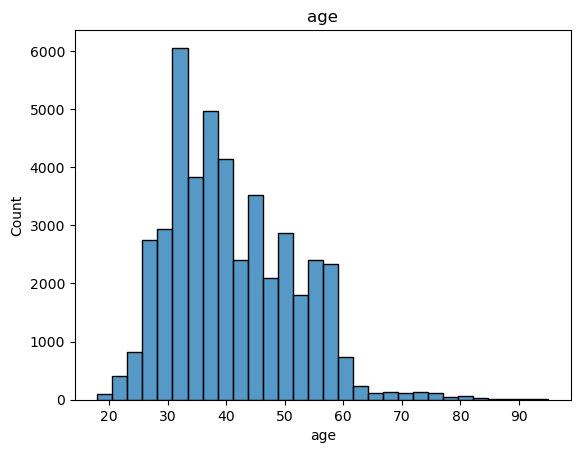

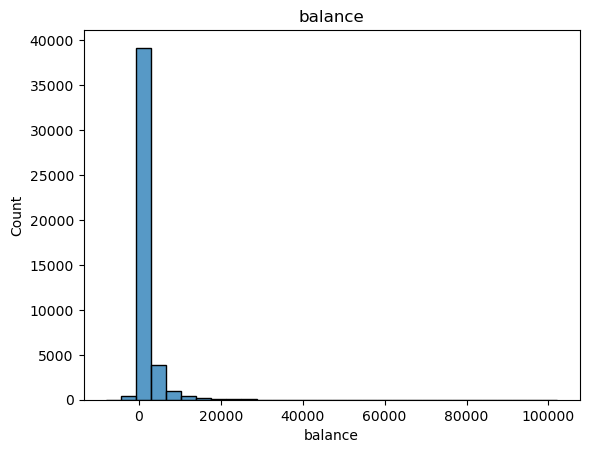

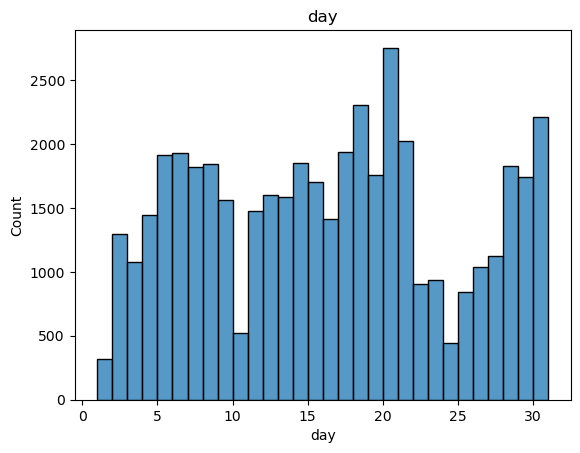

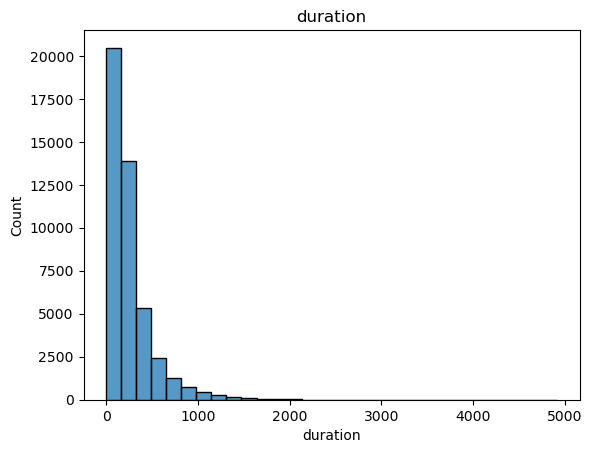

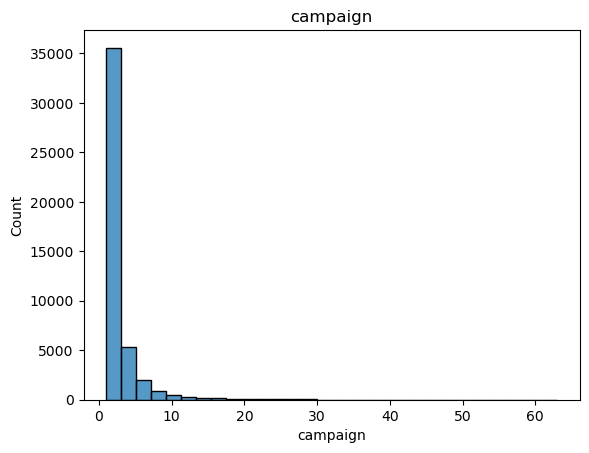

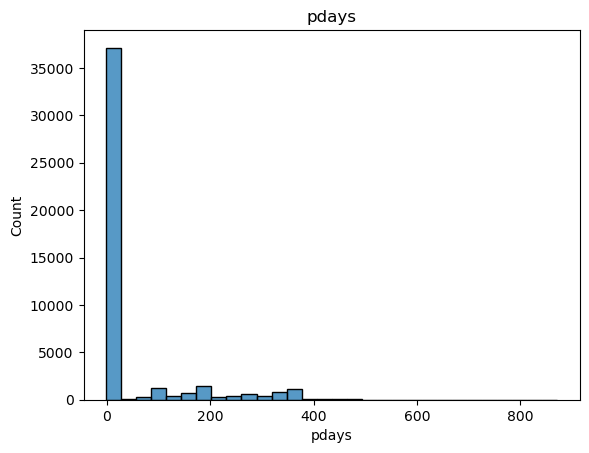

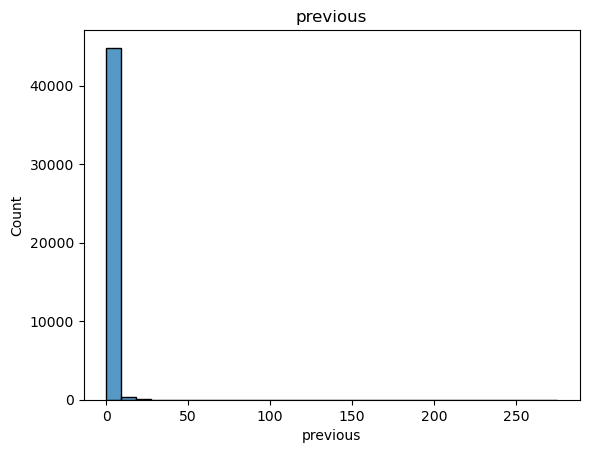

In [6]:
cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

for col in cols:
    plt.figure()
    sns.histplot(df_full[col], bins=30)
    plt.title(col)
    plt.show()

**Xem giá trị tb, trung vị biến liên tục đối với mục tiêu yes/no**
(bỏ days và duration)

<>:12: SyntaxWarning: invalid escape sequence '\Q'
<>:12: SyntaxWarning: invalid escape sequence '\Q'
/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_69109/2441391451.py:12: SyntaxWarning: invalid escape sequence '\Q'
  print("\Quantile by y:")


y                         no          yes
age      mean      40.838986    41.670070
         median    39.000000    38.000000
balance  mean    1303.714969  1804.267915
         median   417.000000   733.000000
duration mean     221.182806   537.294574
         median   164.000000   426.000000
campaign mean       2.846350     2.141047
         median     2.000000     2.000000
pdays    mean      36.421372    68.702968
         median    -1.000000    -1.000000
previous mean       0.502154     1.170354
         median     0.000000     0.000000
\Quantile by y:
           age  balance  duration  campaign  pdays  previous
y                                                           
no  0.25  33.0     58.0      95.0       1.0   -1.0       0.0
    0.50  39.0    417.0     164.0       2.0   -1.0       0.0
    0.75  48.0   1345.0     279.0       3.0   -1.0       0.0
yes 0.25  31.0    210.0     244.0       1.0   -1.0       0.0
    0.50  38.0    733.0     426.0       2.0   -1.0       0.0
    0.75  5

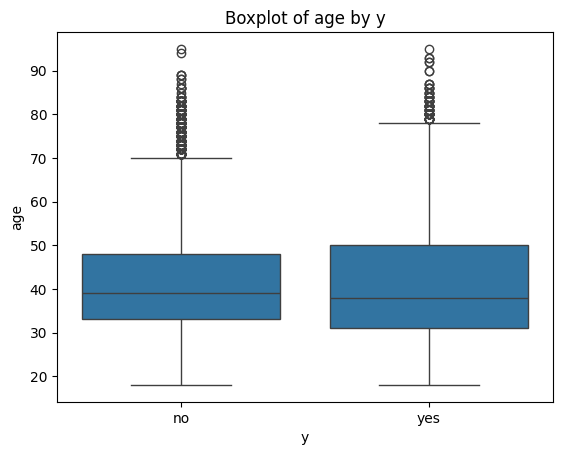

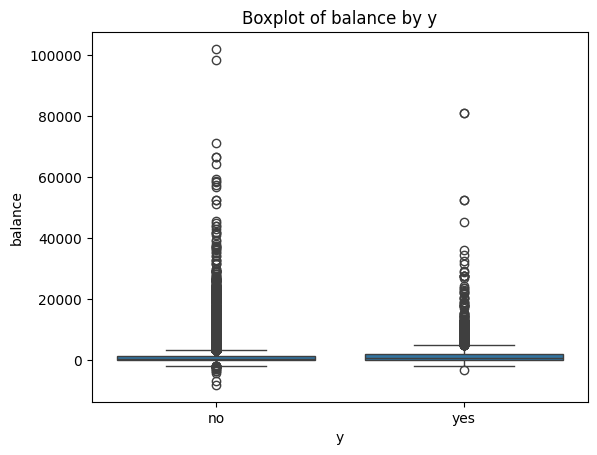

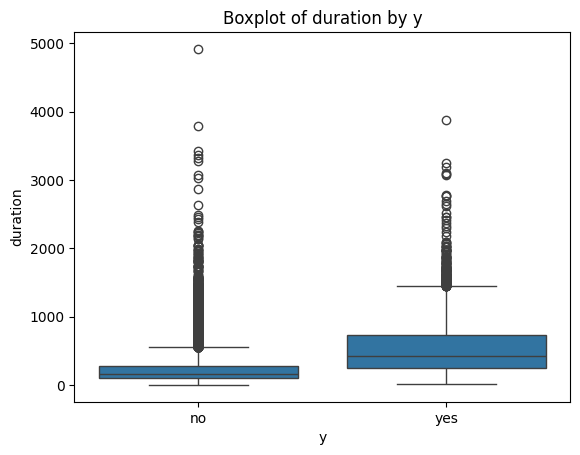

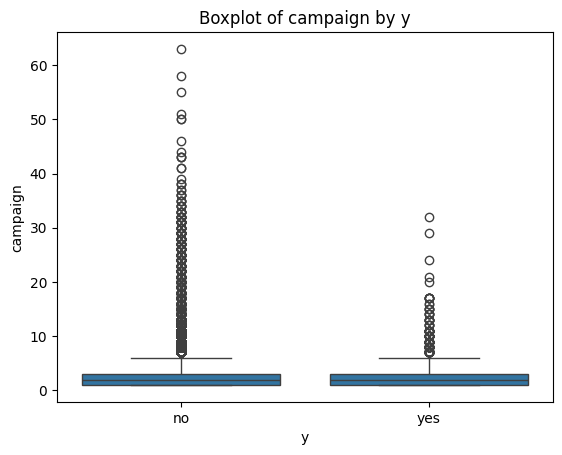

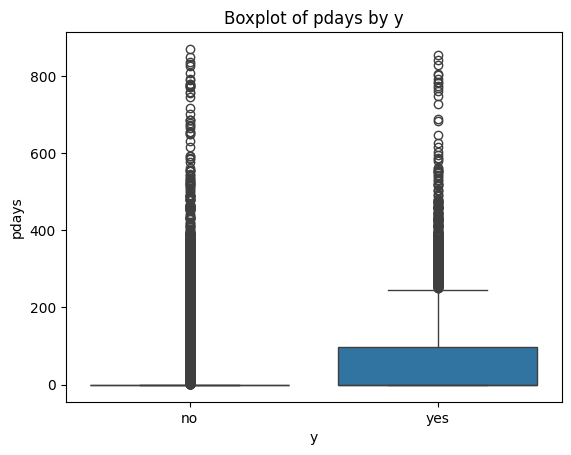

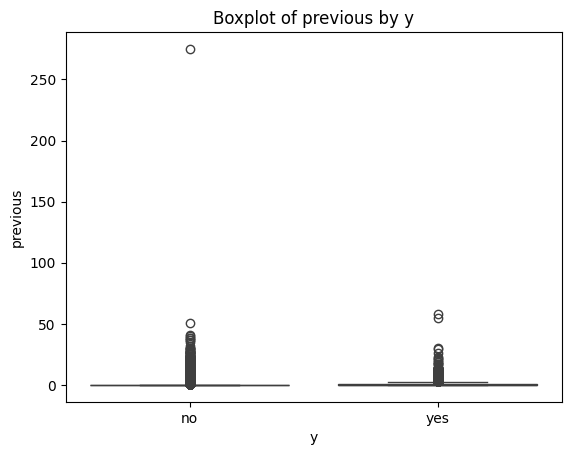


Mann-Whitney U test p-values:
age: p-value = 0.06282
balance: p-value = 0.00000
duration: p-value = 0.00000
campaign: p-value = 0.00000
pdays: p-value = 0.00000
previous: p-value = 0.00000


In [25]:
# =========================
# 1. Lấy biến liên tục (numeric)
# =========================
cols = df_full.select_dtypes(include="number").columns.drop("day")

# =========================
# 2. So sánh thống kê cơ bản (mean, median)
# ⚠️ mean có thể bị lệch nếu có outlier
# =========================
result = df_full.groupby("y")[cols].agg(["mean", "median"])
print(result.T)
print("\Quantile by y:")
print(df_full.groupby("y")[cols].quantile([0.25, 0.5, 0.75]))


# =========================
# 3. Kiểm tra phân phối (tránh bị lệch)
# → dùng boxplot để xem median + outlier
# =========================
for col in cols:
    plt.figure()
    sns.boxplot(x="y", y=col, data=df_full)
    plt.title(f"Boxplot of {col} by y")
    plt.show()


# =========================
# 4. Kiểm định thống kê (Mann-Whitney U test)
# → kiểm tra khác biệt yes/no có ý nghĩa không
# =========================
print("\nMann-Whitney U test p-values:")

for col in cols:
    group_yes = df_full[df_full["y"] == "yes"][col]
    group_no = df_full[df_full["y"] == "no"][col]

    stat, p = mannwhitneyu(group_yes, group_no)

    print(f"{col}: p-value = {p:.5f}")

Các biến số sẽ phân tích: ['age', 'balance', 'campaign', 'pdays', 'previous']

--- Thống kê mô tả (Mean, Median, Std) theo nhóm y ---
y                         no          yes
age      mean      40.838986    41.670070
         median    39.000000    38.000000
         std       10.172662    13.497781
balance  mean    1303.714969  1804.267915
         median   417.000000   733.000000
         std     2974.195473  3501.104777
campaign mean       2.846350     2.141047
         median     2.000000     2.000000
         std        3.212767     1.921826
pdays    mean      36.421372    68.702968
         median    -1.000000    -1.000000
         std       96.757135   118.822266
previous mean       0.502154     1.170354
         median     0.000000     0.000000
         std        2.256771     2.553272

--- Phân vị (Quantiles: 25%, 50%, 75%) theo nhóm y ---
           age  balance  campaign  pdays  previous
y                                                 
no  0.25  33.0     58.0       1.0   

C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[

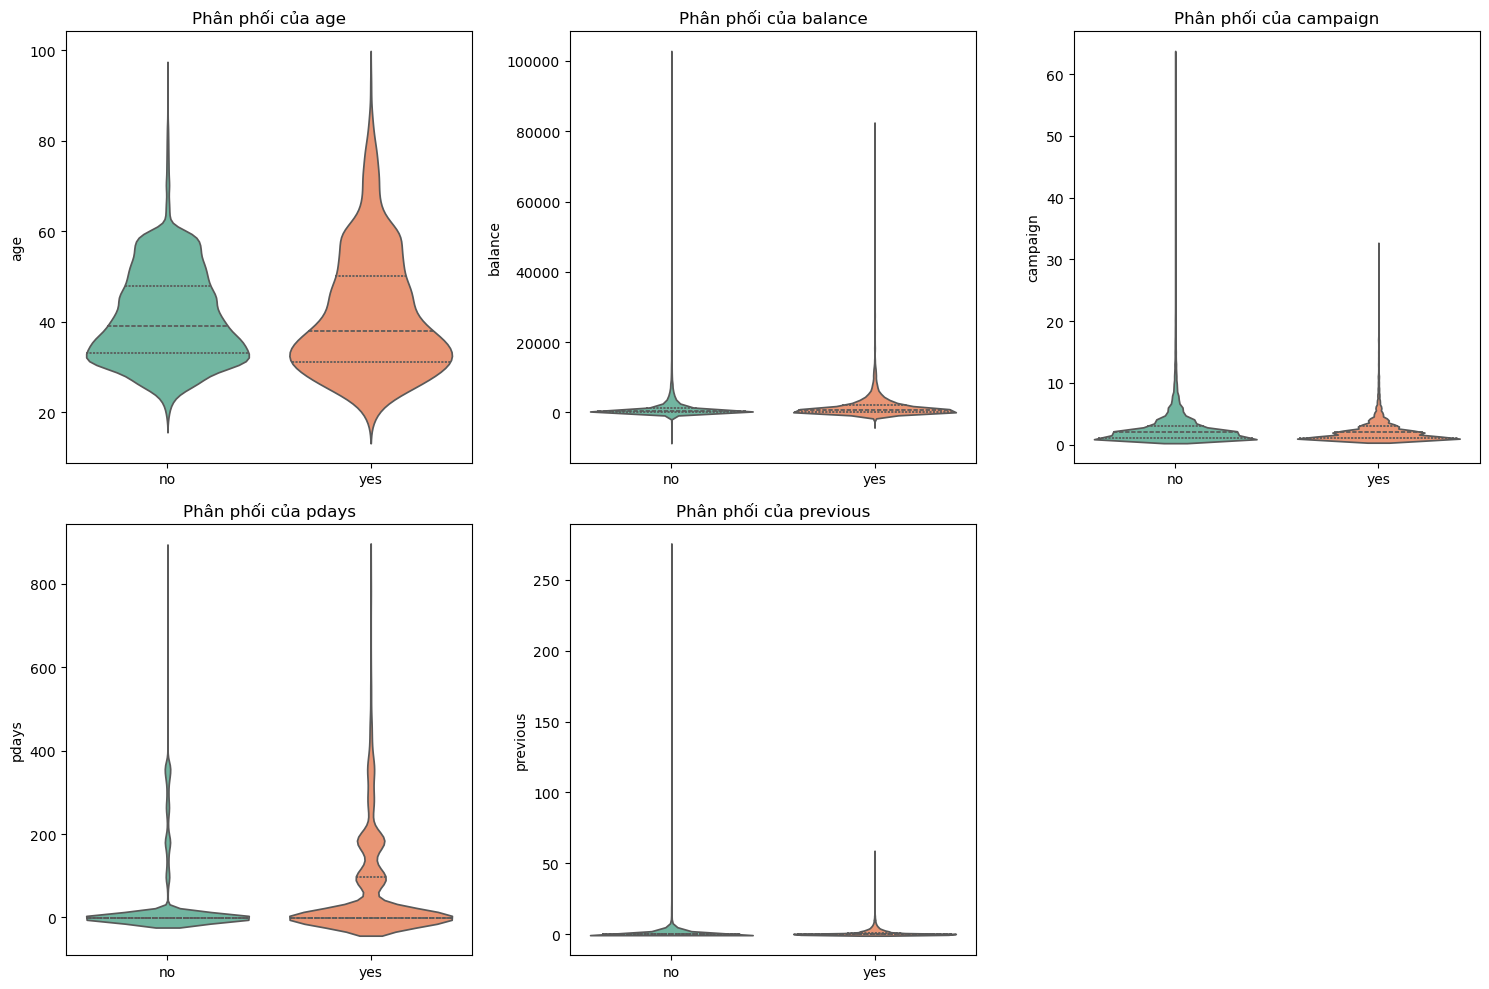


--- Mann-Whitney U test p-values ---
age            : p-value = 0.06282 (Không ý nghĩa)
balance        : p-value = 0.00000 (Có ý nghĩa)
campaign       : p-value = 0.00000 (Có ý nghĩa)
pdays          : p-value = 0.00000 (Có ý nghĩa)
previous       : p-value = 0.00000 (Có ý nghĩa)


In [21]:
# =========================
# 1. Lấy biến liên tục (loại bỏ day và duration)
# =========================
exclude_cols = ["day", "duration"]
# Lọc lấy các cột dạng số và không nằm trong danh sách loại trừ
cols = [c for c in df_full.select_dtypes(include="number").columns if c not in exclude_cols]

print(f"Các biến số sẽ phân tích: {cols}\n")

# =========================
# 2. So sánh thống kê mô tả
# =========================
print("--- Thống kê mô tả (Mean, Median, Std) theo nhóm y ---")
result_stats = df_full.groupby("y")[cols].agg(["mean", "median", "std"])
print(result_stats.T)

print("\n--- Phân vị (Quantiles: 25%, 50%, 75%) theo nhóm y ---")
# Transpose (.T) để bảng hiển thị dọc, dễ so sánh các biến hơn
result_quantiles = df_full.groupby("y")[cols].quantile([0.25, 0.5, 0.75])
print(result_quantiles)

# =========================
# 3. Trực quan hóa (Violin Plot trên Lưới)
# -> Giúp xem cả phân phối, median, outlier và tiết kiệm bộ nhớ
# =========================
num_cols = len(cols)
cols_per_row = 3 # Số lượng biểu đồ trên 1 hàng
rows = math.ceil(num_cols / cols_per_row)

# Khởi tạo khung vẽ tổng thể
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
axes = axes.flatten() # Trải phẳng mảng lưới để dễ lặp qua từng ô

for i, col in enumerate(cols):
    # Dùng violinplot với inner="quartile" để hiện luôn các mốc phân vị bên trong
    sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_xlabel("") # Ẩn tên trục x để đỡ rối

# Xóa các ô trống dư thừa nếu số lượng biến không lấp đầy hàng cuối cùng
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =========================
# 4. Kiểm định thống kê (Mann-Whitney U test)
# =========================
print("\n--- Mann-Whitney U test p-values ---")
for col in cols:
    # Lọc dữ liệu theo nhóm
    group_yes = df_full[df_full["y"] == "yes"][col]
    group_no = df_full[df_full["y"] == "no"][col]
    
    # Bỏ qua các giá trị NaN (nếu có) để kiểm định không bị lỗi
    stat, p = mannwhitneyu(group_yes.dropna(), group_no.dropna(), alternative='two-sided')
    
    # Đánh giá nhanh kết quả
    status = "Có ý nghĩa" if p < 0.05 else "Không ý nghĩa"
    print(f"{col:15}: p-value = {p:.5f} ({status})")

**Biến phân loại so với tương quan yes**


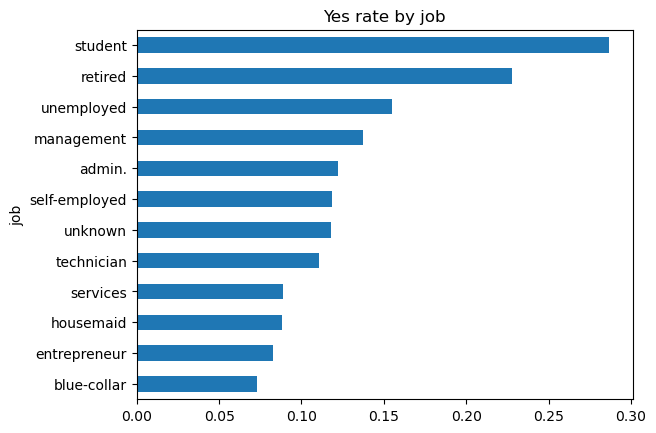

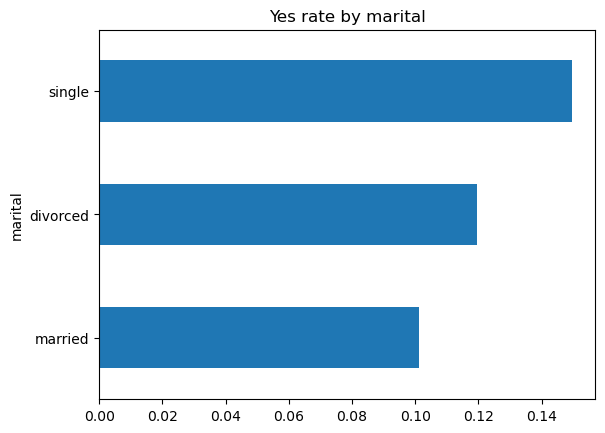

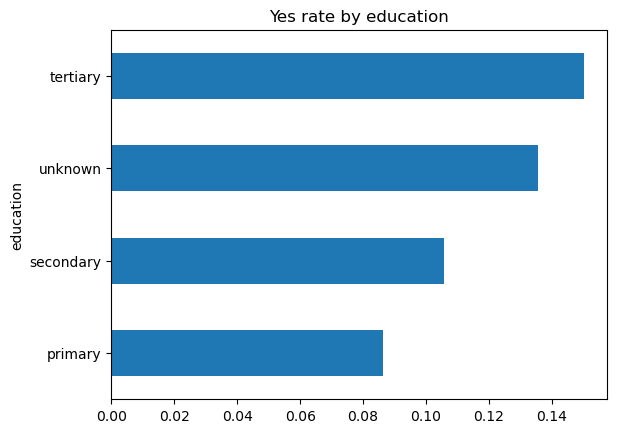

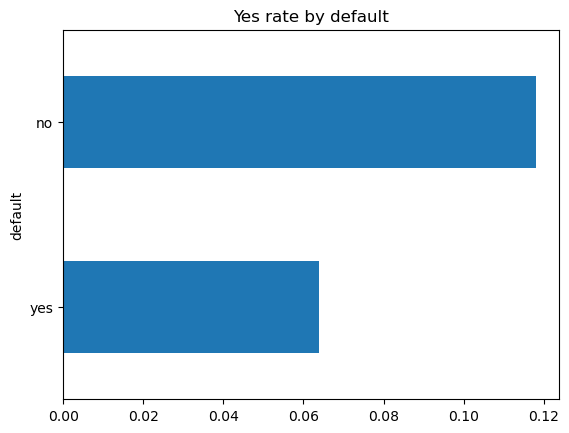

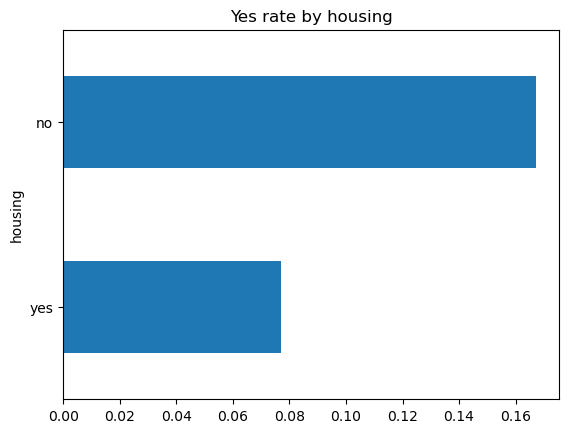

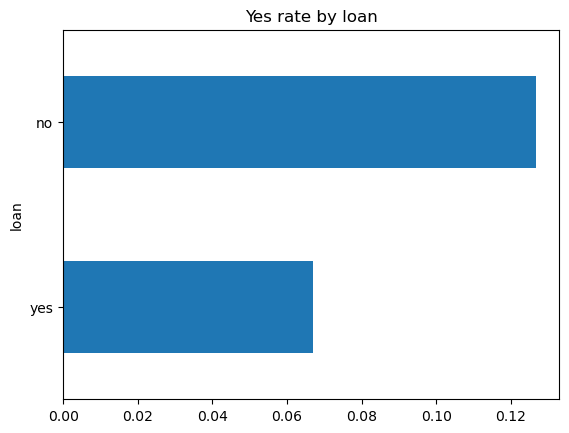

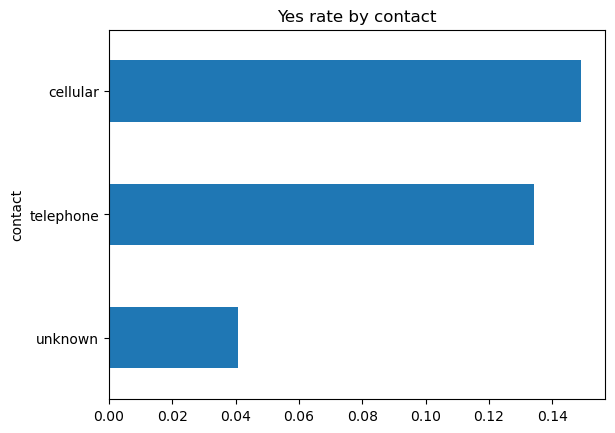

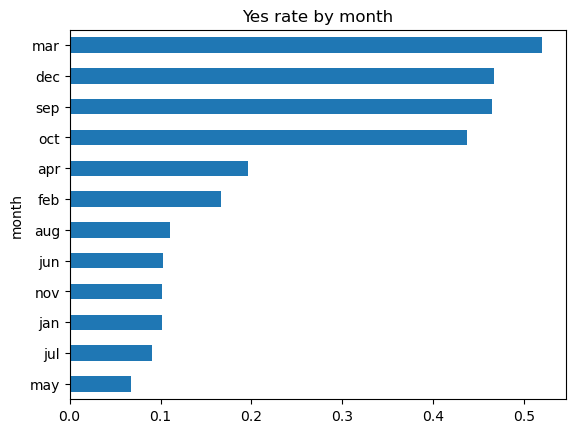

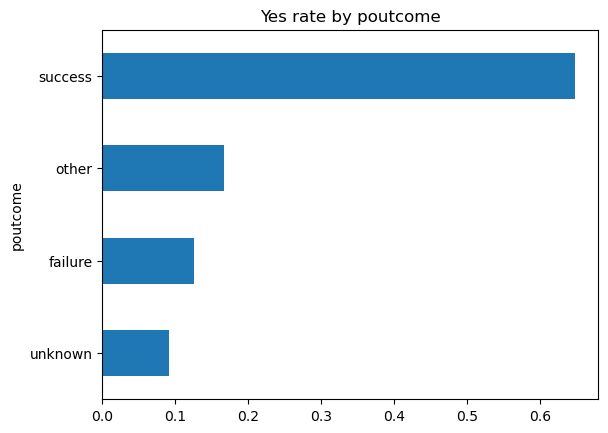

In [11]:
cat_cols = df_full.select_dtypes(include="object").columns.drop("y")

for col in cat_cols:
    table = pd.crosstab(df_full[col], df_full["y"], normalize="index")
    yes_rate = table["yes"].sort_values()

    plt.figure()
    yes_rate.plot(kind="barh")
    plt.title(f"Yes rate by {col}")
    plt.show()

**Biến phân loại so với tương quan no**


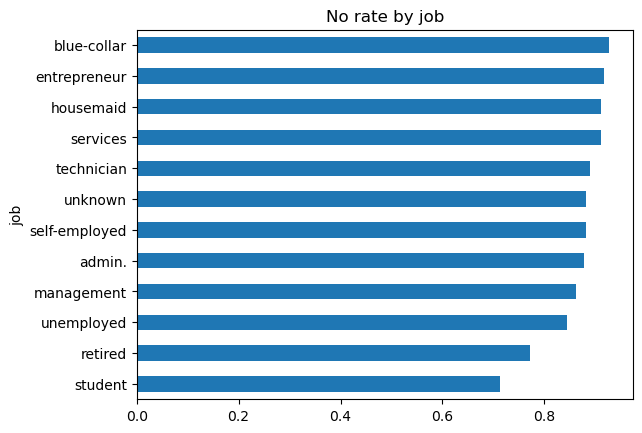

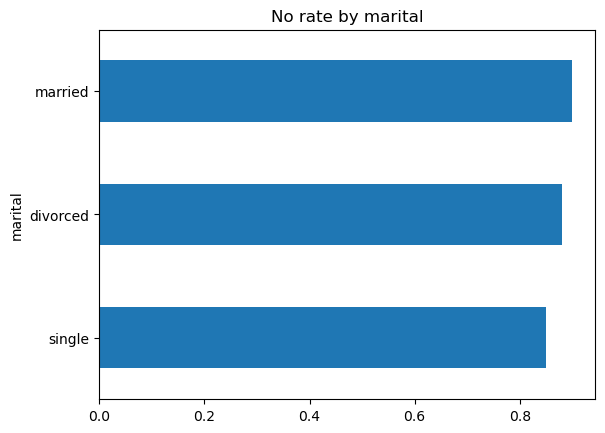

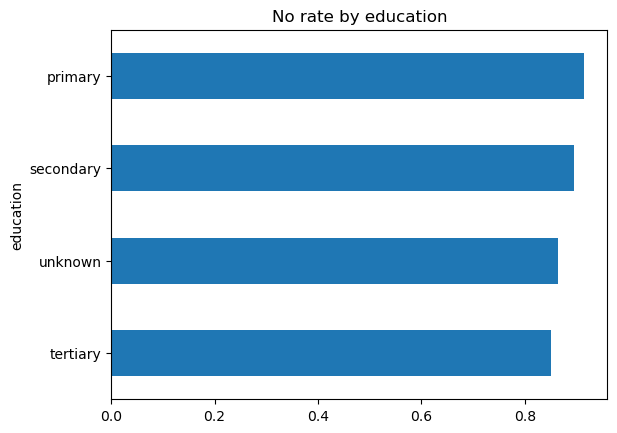

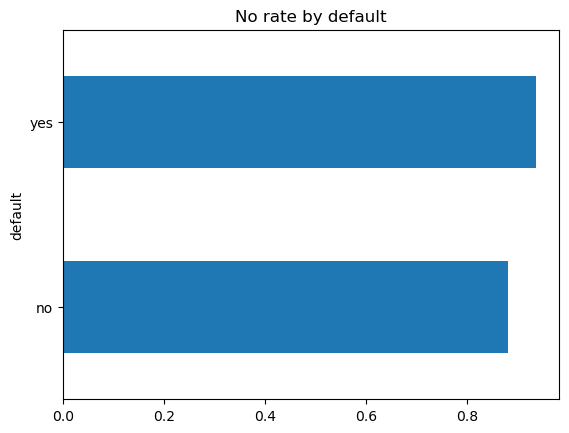

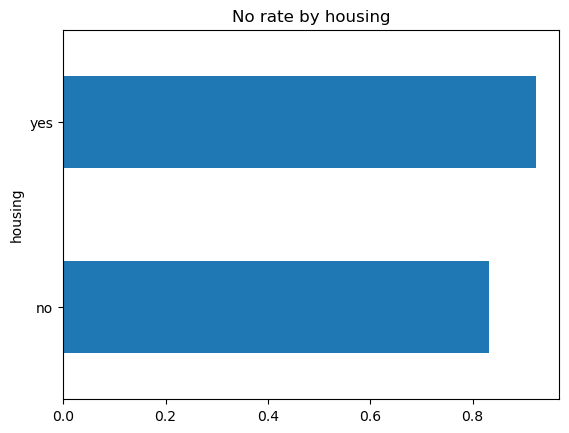

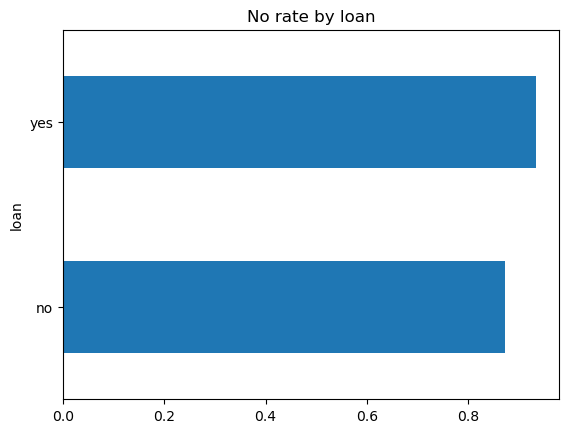

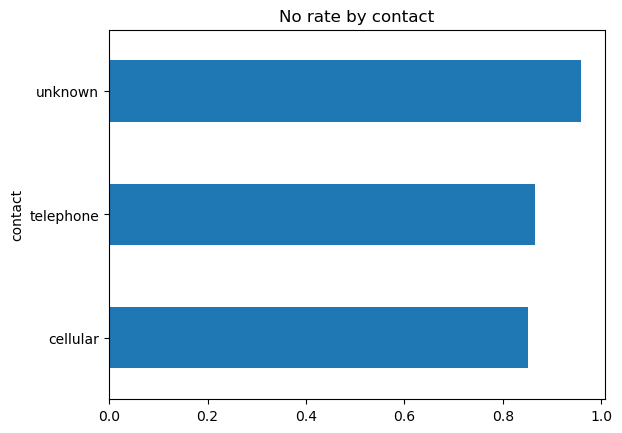

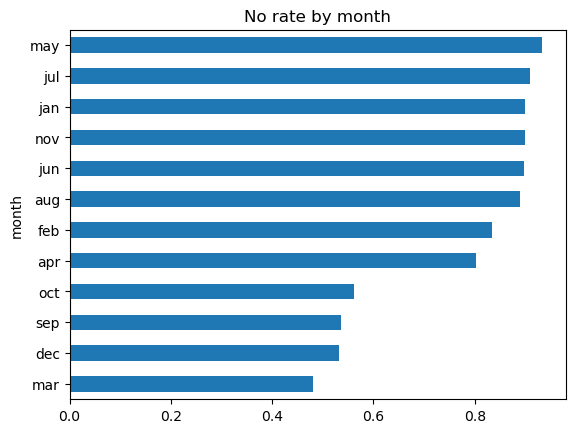

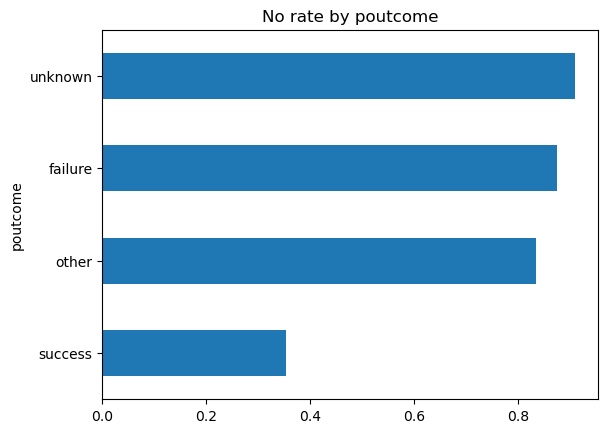

In [15]:
cat_cols = df_full.select_dtypes(include="object").columns.drop("y")

for col in cat_cols:
    table = pd.crosstab(df_full[col], df_full["y"], normalize="index")
    yes_rate = table["no"].sort_values()

    plt.figure()
    yes_rate.plot(kind="barh")
    plt.title(f"No rate by {col}")
    plt.show()

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 28.2 MB/s eta 0:00:00 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
--- 1. Dữ liệu sau khi chuẩn hóa Z-score (5 dòng đầu) ---
        age   balance  duration  campaign     pdays  previous
0  1.606965  0.256419  0.011016 -0.569351 -0.411453  -0.25194
1  0.288529 -0.437895 -0.416127 -0.569351 -0.411453  -0.25194
2 -0.747384 -0.446762 -0.707361 -0.569351 -0.411453  -0.25194
3  0.571051  0.047205 -0.645231 -0.569351 -0.411453  -0.25194
4 -0.747384 -0.447091 -0.233620 -0.569351 -0.411453  -0.25194 



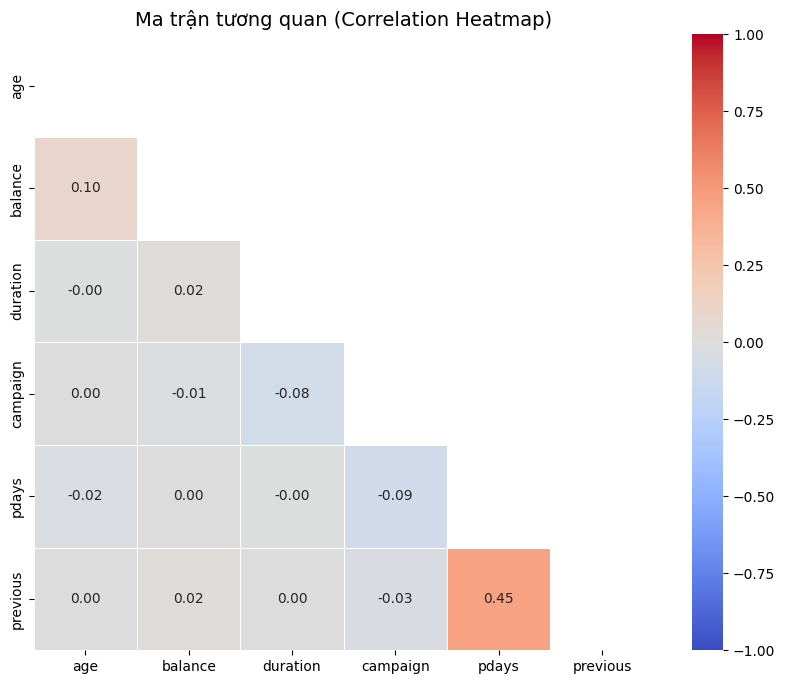

--- 2. Hệ số phóng đại phương sai (VIF) ---
pdays          : VIF =  1.27 -> 🟢 An toàn
previous       : VIF =  1.26 -> 🟢 An toàn
campaign       : VIF =  1.02 -> 🟢 An toàn
balance        : VIF =  1.01 -> 🟢 An toàn
age            : VIF =  1.01 -> 🟢 An toàn
duration       : VIF =  1.01 -> 🟢 An toàn


In [ ]:
# Đảm bảo 'cols' là danh sách các biến liên tục bạn đã lọc ở bước trước
# cols = [c for c in df_full.select_dtypes(include="number").columns if c not in ["day", "duration"]]

# ==========================================
# Bước 1: Chuẩn hóa dữ liệu bằng Z-score
# ==========================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_full[cols]), columns=cols)

print("--- 1. Dữ liệu sau khi chuẩn hóa Z-score (5 dòng đầu) ---")
print(df_scaled.head(), "\n")

# ==========================================
# Bước 2: Ma trận tương quan (Pearson Correlation)
# ==========================================
corr_matrix = df_scaled.corr()

plt.figure(figsize=(10, 8))
# Tạo mask để ẩn nửa trên của ma trận (vì nó đối xứng, ẩn đi cho đỡ rối mắt)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Vẽ Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", 
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan (Correlation Heatmap)", fontsize=14)
plt.show()

# ==========================================
# Bước 3: Kiểm tra Đa cộng tuyến bằng VIF (Variance Inflation Factor)
# ==========================================
print("--- 2. Hệ số phóng đại phương sai (VIF) ---")

# Khởi tạo bảng chứa kết quả VIF
vif_data = pd.DataFrame()
vif_data["Biến (Feature)"] = df_scaled.columns

# Tính VIF cho từng biến số
# Lưu ý: Vì dữ liệu đã chuẩn hóa Z-score (mean=0), ta có thể tính trực tiếp mà không cần thêm hằng số (add_constant)
vif_data["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

# Sắp xếp VIF giảm dần để dễ rà soát
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# In kết quả và đánh giá tự động
for index, row in vif_data.iterrows():
    vif_val = row["VIF"]
    feature = row["Biến (Feature)"]
    
    # Đặt ngưỡng cảnh báo: VIF > 5 là đáng lo ngại, VIF > 10 là đa cộng tuyến rất nặng
    if vif_val >= 10:
        status = "🔴 Đa cộng tuyến RẤT NẶNG (Nên loại bỏ)"
    elif vif_val >= 5:
        status = "🟡 Nguy cơ cao (Cần xem xét)"
    else:
        status = "🟢 An toàn"
        
    print(f"{feature:15}: VIF = {vif_val:5.2f} -> {status}")

**MODEL**


chia dữ liệu 80/20, stratified. Lưu ý: ở đây k sử dụng LabelEncoding vì làm mô hình sai lệch khi cho rằng một giá trị chữ (phân loại) như student =1 sẽ thua gấp đôi technician =2. Dùng One-hot Encoding cho biến phân loại, và Z-Score cho biến liên tục

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==========================================
# 1. Tiền xử lý cơ bản, loại bỏ các cột không cần thiết
# ==========================================
df = df_full.drop(columns=['day', 'duration'])

X = df.drop(columns=['y'])
y = df['y']

# ==========================================
# 2. Phân loại cột Số và cột Chữ
# ==========================================
# Lấy danh sách này NGAY TỪ ĐẦU để lát nữa biết đường chỉ scale các cột số gốc
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ==========================================
# 3. Mã hóa Dữ liệu (Encoding)
# ==========================================
# A. LabelEncoder cho nhãn y
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y) 

# B. One-Hot Encoding cho tập X
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

# ==========================================
# 4. Chia tập Train / Test (Stratified)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.2,       
    stratify=y_encoded,  
    random_state=42      
)

# Tạo bản sao độc lập để Pandas không báo lỗi SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# ==========================================
# 5. Chuẩn hóa Z-score (StandardScaler)
# ==========================================
scaler = StandardScaler()

# CHÚ Ý: Chỉ fit (tính mean, std) trên tập Train và transform luôn
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Đối với tập Test, CHỈ transform dựa trên mean và std đã học từ tập Train
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ==========================================
# 6. Kiểm tra lại kết quả
# ==========================================
print("✅ HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHO LOGISTIC REGRESSION!\n")

print("--- Thống kê vài cột số trong X_train sau Z-score (Mean ~ 0, Std ~ 1) ---")
print(X_train[num_cols].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\n--- Kích thước dữ liệu cuối cùng ---")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

✅ HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHO LOGISTIC REGRESSION!

--- Thống kê vài cột số trong X_train sau Z-score (Mean ~ 0, Std ~ 1) ---
        age  balance  campaign  pdays  previous
mean -0.000   -0.000     0.000  0.000    -0.000
std   1.000    1.000     1.000  1.000     1.000
min  -2.154   -3.058    -0.568 -0.411    -0.242
max   5.091   32.837    19.405  8.295   113.926

--- Kích thước dữ liệu cuối cùng ---
X_train: (36168, 40)
X_test : (9043, 40)


Chạy mô hình (có dùng class_weighted để mô hình tập trung vào nhãn yes hơn)

⏳ Đang huấn luyện mô hình Logistic Regression...
✅ HUẤN LUYỆN HOÀN TẤT! DƯỚI ĐÂY LÀ KẾT QUẢ:

--- 1. Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.27      0.63      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043

--- 2. Chỉ số ROC-AUC Score: 0.7722 ---
💡 Đánh giá: Mô hình phân loại TỐT.

--- 3. Ma trận nhầm lẫn (Confusion Matrix) ---


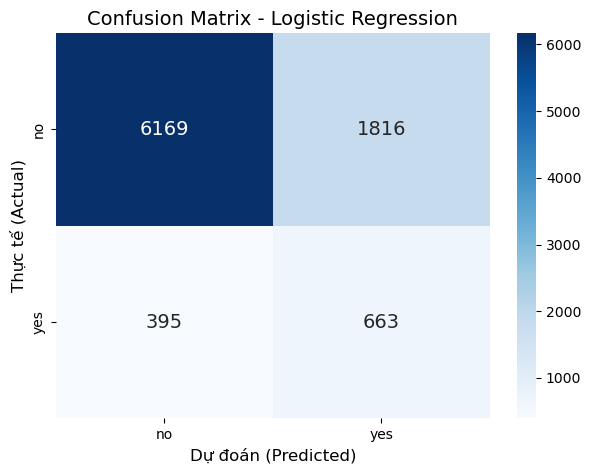

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Khởi tạo và Huấn luyện mô hình (Training)
# ==========================================
print("⏳ Đang huấn luyện mô hình Logistic Regression...")

# Dùng class_weight='balanced' để xử lý data mất cân bằng (Imbalanced Data)
# max_iter=1000 giúp mô hình có đủ thời gian để hội tụ
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# ==========================================
# 2. Dự đoán trên tập Test
# ==========================================
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1] # Lấy xác suất dự đoán là 1 (Yes)

# ==========================================
# 3. Đánh giá Mô hình (Evaluation)
# ==========================================
print("✅ HUẤN LUYỆN HOÀN TẤT! DƯỚI ĐÂY LÀ KẾT QUẢ:\n")

# --- A. Báo cáo phân loại (Classification Report) ---
print("--- 1. Báo cáo phân loại (Classification Report) ---")
# Lấy lại tên nhãn gốc từ LabelEncoder ('no', 'yes') để in cho dễ đọc
target_names = le_y.classes_ 
print(classification_report(y_test, y_pred, target_names=target_names))

# --- B. Đánh giá bằng ROC-AUC ---
# AUC là thang đo rất tốt cho dữ liệu mất cân bằng (1 là hoàn hảo, 0.5 là đoán bừa)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"--- 2. Chỉ số ROC-AUC Score: {auc_score:.4f} ---")
if auc_score >= 0.8:
    print("💡 Đánh giá: Mô hình có khả năng phân loại RẤT TỐT!")
elif auc_score >= 0.7:
    print("💡 Đánh giá: Mô hình phân loại TỐT.")
else:
    print("💡 Đánh giá: Mô hình phân loại TRUNG BÌNH/YẾU.")

# --- C. Ma trận nhầm lẫn (Confusion Matrix) ---
print("\n--- 3. Ma trận nhầm lẫn (Confusion Matrix) ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14}) # Phóng to số cho dễ nhìn
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

Một số pp tinh chỉnh cải thiện FALSE POSITIVE (Mặc dù mô hình baseline ở trên có FALSE NEGATIVE THẤP NHƯNG FALSE POSITIVE CAO -> làm tăng chi phí lãng phí vì phải gọi thêm những thằng tưởng là tiềm năng nhưng k). TUY NHIÊN CHỈ LÀ TEST THÔI VÌ CƠ BẢN THÌ FALSE NEGATIVE mới tạo ra lợi nhuận -> cần tìm điểm cân bằng (nhưng như v quá phức tạp cho baseline nên thôi)

🚀 BẮT ĐẦU CHẠY 4 KỊCH BẢN CẢI THIỆN MÔ HÌNH

⏳ 1. Đang xử lý: Dời ngưỡng quyết định (0.65)...
              precision    recall  f1-score   support

          no       0.93      0.85      0.89      7985
         yes       0.33      0.55      0.41      1058

    accuracy                           0.82      9043
   macro avg       0.63      0.70      0.65      9043
weighted avg       0.86      0.82      0.84      9043

🌟 ROC-AUC Score (Dựa trên xác suất gốc): 0.7722

--------------------------------------------------
⏳ 2. Đang xử lý: Tùy chỉnh trọng số (1:5)...
              precision    recall  f1-score   support

          no       0.93      0.86      0.90      7985
         yes       0.34      0.54      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.82      0.84      9043

🌟 ROC-AUC Score: 0.7722

--------------------------------------------------
⏳ 3. Đang xử lý: Tìm kiếm siêu 

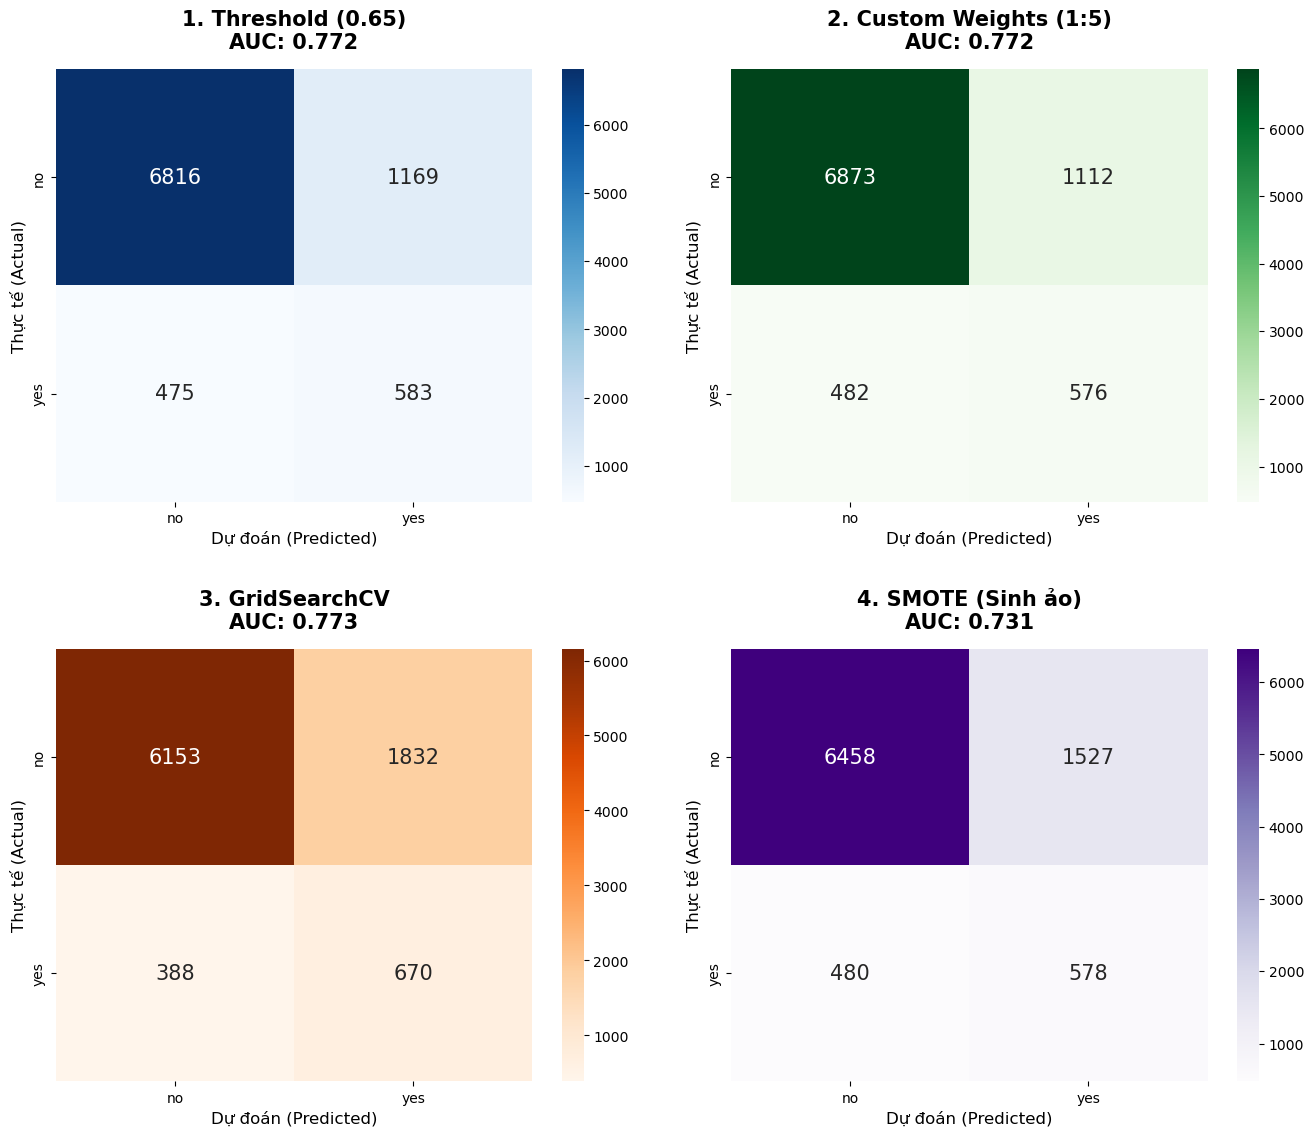

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV

print("="*60)
print("🚀 BẮT ĐẦU CHẠY 4 KỊCH BẢN CẢI THIỆN MÔ HÌNH")
print("="*60 + "\n")

# Lấy lại tên nhãn gốc (nếu bạn chưa định nghĩa thì mặc định là 'no' và 'yes')
try:
    target_names = le_y.classes_
except NameError:
    target_names = ['no', 'yes']

# =====================================================================
# 1. THRESHOLD TUNING (Tăng ngưỡng lên 0.65 để giảm False Positive)
# =====================================================================
print("⏳ 1. Đang xử lý: Dời ngưỡng quyết định (0.65)...")
custom_threshold = 0.55
y_pred_1 = (y_pred_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_1, target_names=target_names))
# Lưu ý: AUC của phương pháp này bằng y hệt Baseline vì AUC đo trên xác suất (y_pred_proba) 
# chứ không đo trên nhãn đã ép ngưỡng.
auc_1 = roc_auc_score(y_test, y_pred_proba)
print(f"🌟 ROC-AUC Score (Dựa trên xác suất gốc): {auc_1:.4f}\n")
print("-" * 50)

# =====================================================================
# 2. CUSTOM CLASS WEIGHTS (Tùy chỉnh phạt sai Yes nhẹ hơn: 1 vs 5)
# =====================================================================
print("⏳ 2. Đang xử lý: Tùy chỉnh trọng số (1:5)...")
log_reg_cw = LogisticRegression(class_weight={0: 1, 1: 6}, max_iter=1000, random_state=42)
log_reg_cw.fit(X_train, y_train)

y_pred_2 = log_reg_cw.predict(X_test)
y_proba_2 = log_reg_cw.predict_proba(X_test)[:, 1] # Lấy xác suất để tính AUC

print(classification_report(y_test, y_pred_2, target_names=target_names))
auc_2 = roc_auc_score(y_test, y_proba_2)
print(f"🌟 ROC-AUC Score: {auc_2:.4f}\n")
print("-" * 50)

# =====================================================================
# 3. GRIDSEARCH CV (Cho máy tự tìm tham số tối ưu)
# =====================================================================
print("⏳ 3. Đang xử lý: Tìm kiếm siêu tham số tối ưu (GridSearchCV)...")
# Đã thu gọn tham số C để máy chạy nhanh hơn
param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear']} 
grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_3 = best_model.predict(X_test)
y_proba_3 = best_model.predict_proba(X_test)[:, 1]

print(f"(Tham số tốt nhất tìm được: {grid_search.best_params_})")
print(classification_report(y_test, y_pred_3, target_names=target_names))
auc_3 = roc_auc_score(y_test, y_proba_3)
print(f"🌟 ROC-AUC Score: {auc_3:.4f}\n")
print("-" * 50)

# =====================================================================
# 4. SMOTE (Sinh dữ liệu ảo để cân bằng hoàn toàn 50/50)
# =====================================================================
print("⏳ 4. Đang xử lý: Cân bằng dữ liệu bằng SMOTE...")
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
    log_reg_smote.fit(X_train_smote, y_train_smote)
    
    y_pred_4 = log_reg_smote.predict(X_test)
    y_proba_4 = log_reg_smote.predict_proba(X_test)[:, 1]
    method_4_title = "4. SMOTE (Sinh ảo)"
    
    print(classification_report(y_test, y_pred_4, target_names=target_names))
    auc_4 = roc_auc_score(y_test, y_proba_4)
    print(f"🌟 ROC-AUC Score: {auc_4:.4f}\n")

except ImportError:
    print("⚠️ CẢNH BÁO: Bạn chưa cài 'imbalanced-learn'. Đang chạy Fallback (Ngưỡng 0.3)...")
    y_pred_4 = (y_pred_proba >= 0.3).astype(int)
    method_4_title = "4. Fallback: Threshold 0.3"
    print(classification_report(y_test, y_pred_4, target_names=target_names))
    auc_4 = roc_auc_score(y_test, y_pred_proba) # AUC không đổi khi chỉnh threshold
    print(f"🌟 ROC-AUC Score (Dựa trên xác suất gốc): {auc_4:.4f}\n")


# =====================================================================
# VẼ BIỂU ĐỒ TỔNG HỢP (GRID 2x2 CONFUSION MATRIX)
# =====================================================================
print("✅ HOÀN TẤT! Đang xuất biểu đồ so sánh...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plots_config = [
    (y_pred_1, f"1. Threshold (0.65)\nAUC: {auc_1:.3f}", axes[0, 0], "Blues"),
    (y_pred_2, f"2. Custom Weights (1:5)\nAUC: {auc_2:.3f}", axes[0, 1], "Greens"),
    (y_pred_3, f"3. GridSearchCV\nAUC: {auc_3:.3f}", axes[1, 0], "Oranges"),
    (y_pred_4, f"{method_4_title}\nAUC: {auc_4:.3f}", axes[1, 1], "Purples")
]

for y_pred_custom, title, ax, cmap in plots_config:
    cm = confusion_matrix(y_test, y_pred_custom)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 15})
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Thực tế (Actual)', fontsize=12)
    ax.set_xlabel('Dự đoán (Predicted)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

**XGBoost**

⏳ Đang huấn luyện XGBoost Baseline (Không kỹ thuật)...
✅ KẾT QUẢ XGBOOST BASELINE:

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.61      0.24      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.61      0.64      9043
weighted avg       0.87      0.89      0.87      9043

🌟 ROC-AUC Score: 0.7732


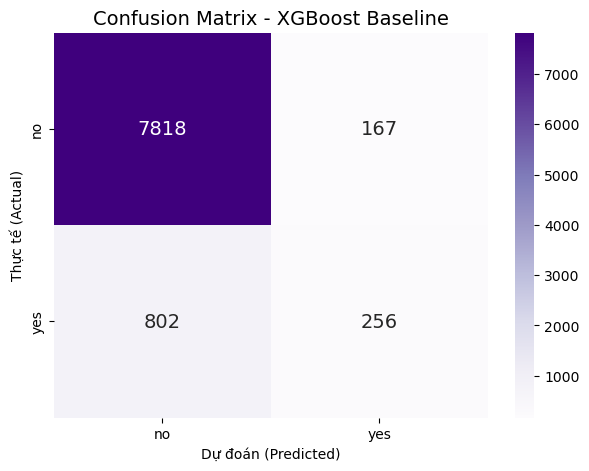

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Khởi tạo và Huấn luyện XGBoost Baseline
# ==========================================
print("⏳ Đang huấn luyện XGBoost Baseline (Không kỹ thuật)...")

# Chỉ để mặc định các tham số cơ bản
xgb_baseline = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)

# ==========================================
# 2. Dự đoán
# ==========================================
y_pred_xgb = xgb_baseline.predict(X_test)
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

# ==========================================
# 3. Đánh giá
# ==========================================
print("✅ KẾT QUẢ XGBOOST BASELINE:\n")

target_names = le_y.classes_ if 'le_y' in locals() else ['no', 'yes']
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"🌟 ROC-AUC Score: {auc_xgb:.4f}")

# --- Vẽ Confusion Matrix ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14})
plt.title('Confusion Matrix - XGBoost Baseline', fontsize=14)
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

Kiểm tra mức độ gain khi chia nhánh (xét độ quan trọng của mỗi biến)

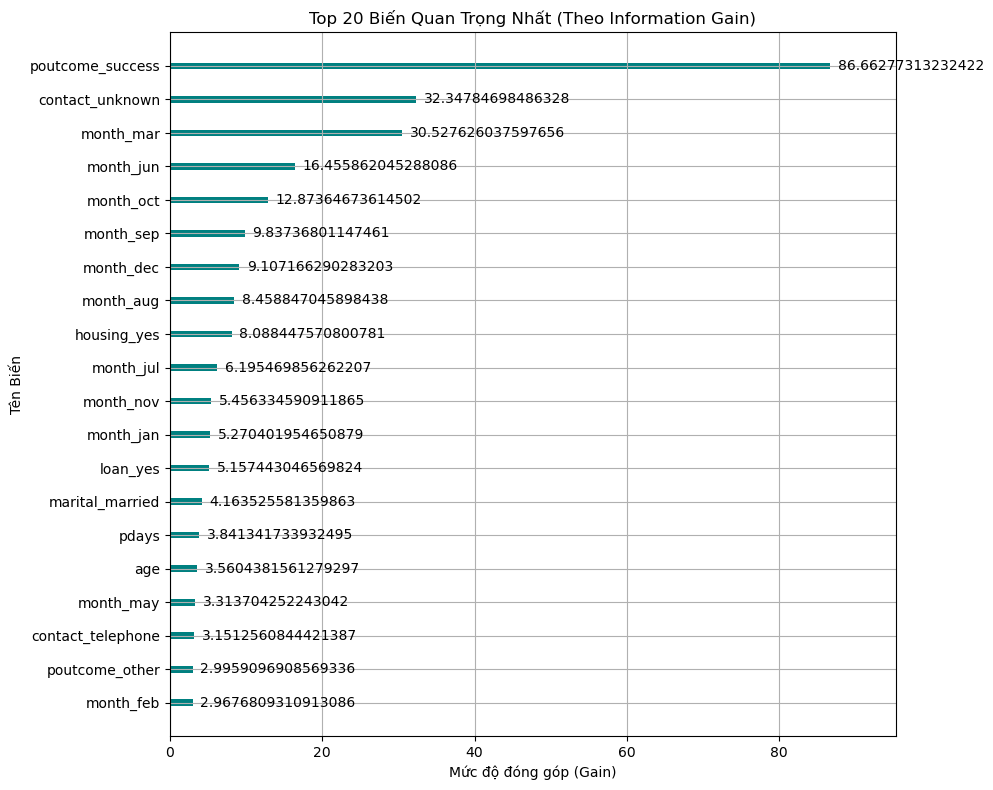

In [57]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Tạo khung hình với kích thước lớn
fig, ax = plt.subplots(figsize=(10, 8))

# 2. DÙNG XGBOOST ĐỂ VẼ BIỂU ĐỒ 
xgb.plot_importance(
    xgb_baseline, 
    ax=ax,                  # Ép biểu đồ vẽ vào khung hình to ở trên
    max_num_features=20, 
    importance_type='gain', # Tiêu chí đo lường chất lượng
    title='Top 20 Biến Quan Trọng Nhất (Theo Information Gain)',
    xlabel='Mức độ đóng góp (Gain)',
    ylabel='Tên Biến',
    color='teal'            # Thêm chút màu cho đẹp mắt
)

plt.tight_layout()
plt.show()

XÁO TRỘN

⏳ Đang tính toán Permutation Importance (Sẽ mất khoảng 10-30 giây)...


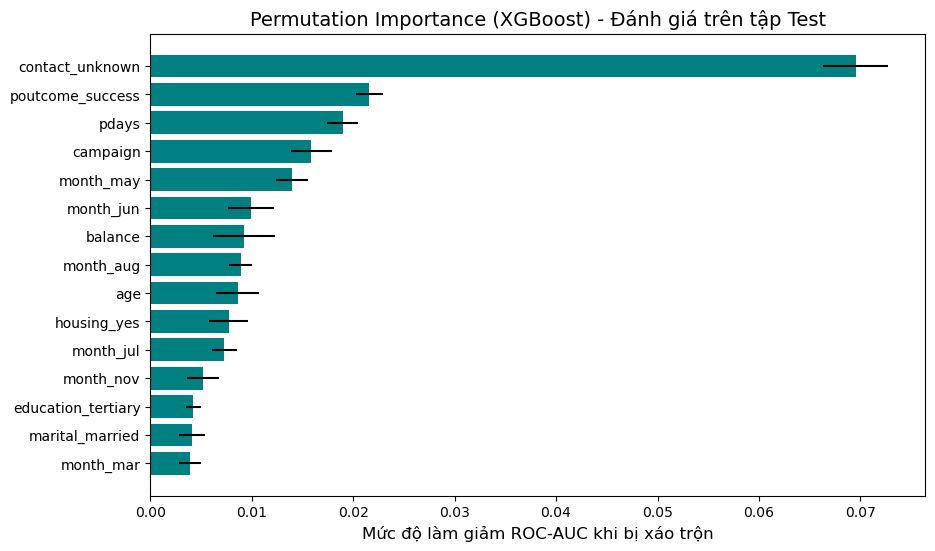

In [55]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang tính toán Permutation Importance (Sẽ mất khoảng 10-30 giây)...")

# Tính toán mức độ giảm điểm ROC-AUC khi xáo trộn từng biến (lặp lại 5 lần để lấy trung bình)
perm_result = permutation_importance(
    xgb_baseline, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=1
)

# Đưa kết quả vào DataFrame cho dễ nhìn
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# Lấy Top 15 biến quan trọng nhất để vẽ
top_perm_df = perm_df.head(15).sort_values(by='Importance_Mean', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(top_perm_df['Feature'], top_perm_df['Importance_Mean'], xerr=top_perm_df['Importance_Std'], color='teal')
plt.title('Permutation Importance (XGBoost) - Đánh giá trên tập Test', fontsize=14)
plt.xlabel('Mức độ làm giảm ROC-AUC khi bị xáo trộn', fontsize=12)
plt.show()

SHAP

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
tensorflow-cpu 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.



INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.8 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 538.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   -- ------------------------------------- 41.0/556.1 kB 1.9 MB/s eta 0:00:01
   ------ --------------------------------- 92.2/556.1 kB 2.6 MB/s eta 0:00:01
   ----------- ---------------------------- 153.6/556.1 kB 1.3 MB/s eta 0:00:01
   ---------------- ----------------------- 225.3/556.1 kB 1.5 MB/s eta 0:00:01
   --------------------------- ------------ 389.1/556.1 kB 1.9 MB/s eta 0:00:01
   ---------------------------------- ----- 481.3/556.1 kB 2.0 MB/s eta 0:00:01
   

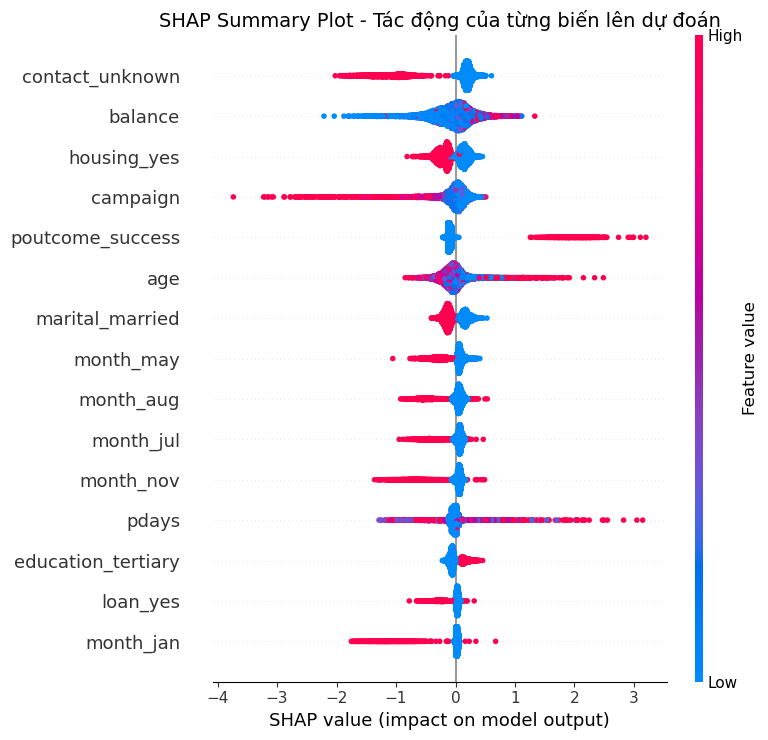

In [56]:
%pip install shap
import shap
import matplotlib.pyplot as plt

print("⏳ Đang tính toán SHAP Values (Có thể mất 1-2 phút tùy cấu hình máy)...")

# 1. Khởi tạo người giải thích (Explainer) chuyên dụng cho mô hình dạng Cây
explainer = shap.TreeExplainer(xgb_baseline)

# 2. Tính toán giá trị SHAP cho toàn bộ tập Test
# (Nếu máy bạn yếu và báo lỗi tràn RAM, hãy thay X_test bằng X_test.sample(1000) để chạy nhanh trên 1000 người thôi)
shap_values = explainer.shap_values(X_test)

# 3. Vẽ biểu đồ Tổng quan (Summary Plot / Beeswarm Plot)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot - Tác động của từng biến lên dự đoán', fontsize=14)

# Lệnh này sẽ tự động vẽ ra một biểu đồ cực kỳ đẹp với các chấm màu
shap.summary_plot(shap_values, X_test, max_display=15, show=False)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING (Bổ sung theo yêu cầu
)

In [48]:
# ==========================================
# FEATURE ENGINEERING: PHÂN TẦNG POUTCOME
# ==========================================

print("=" * 60)
print("1. KIỂM TRA TÍNH NHẤT QUÁN: poutcome vs pdays")
print("=" * 60)
# Kiểm tra xem poutcome='unknown' có khớp với pdays=-1 không
# Đây là bước quan trọng để đảm bảo logic "khách chưa gọi" là chính xác
consistency_check = df_full[
    ((df_full['poutcome'] == 'unknown') & (df_full['pdays'] != -1)) |
    ((df_full['poutcome'] != 'unknown') & (df_full['pdays'] == -1))
]

if len(consistency_check) == 0:
    print("✅ Dữ liệu nhất quán: poutcome='unknown' ⇔ pdays=-1")
    print("   → Có thể dùng poutcome để xác định khách mới/cũ an toàn.")
else:
    print(f"⚠️  Cảnh báo: Có {len(consistency_check)} dòng không nhất quán.")
    print("   → Nên ưu tiên dùng pdays để xác định khách mới/cũ.")

# ==========================================
# 2. TẠO BIẾN PHÂN TẦNG
# ==========================================
df_fe = df_full.copy()

# --- TẦNG 1: Khách đã được gọi trước đó chưa? ---
# is_prev_contacted = 1 nếu là khách cũ, 0 nếu là khách mới
df_fe['is_prev_contacted'] = (df_fe['poutcome'] != 'unknown').astype(int)

# --- TẦNG 2: Trong khách cũ, ai đã đồng ý? ---
# prev_success = 1 nếu success, 0 nếu failure/other/khách mới
# Với khách mới, prev_success = 0 (chưa có lịch sử thành công)
df_fe['prev_success'] = (df_fe['poutcome'] == 'success').astype(int)

# Kiểm tra phân phối
print("\n" + "=" * 60)
print("2. PHÂN PHỐI BIẾN MỚI")
print("=" * 60)
contact_rate = df_fe['is_prev_contacted'].mean() * 100
success_rate = df_fe[df_fe['is_prev_contacted'] == 1]['prev_success'].mean() * 100

print(f"📊 Tỷ lệ khách đã gọi trước đó (is_prev_contacted=1): {contact_rate:.2f}%")
print(f"   → Tỷ lệ khách mới (is_prev_contacted=0): {100-contact_rate:.2f}%")
print(f"   → Khớp với nhận định ~18-82 của bạn! ✅")

print(f"\n📊 Trong nhóm khách cũ, tỷ lệ đã thành công (prev_success=1): {success_rate:.2f}%")

# ==========================================
# 3. KIỂM CHỨNG INSIGHT: CONVERSION RATE THEO TẦNG
# ==========================================
print("\n" + "=" * 60)
print("3. KIỂM CHỨNG HIỆU QUẢ PHÂN TẦNG")
print("=" * 60)

# Tạo nhóm kết hợp để phân tích
df_fe['customer_segment'] = 'new'
df_fe.loc[df_fe['is_prev_contacted'] == 1, 'customer_segment'] = 'old_no_success'
df_fe.loc[df_fe['prev_success'] == 1, 'customer_segment'] = 'old_success'

segment_stats = df_fe.groupby('customer_segment')['y'].agg(
    count='count',
    yes=lambda x: (x == 'yes').sum(),
    conversion_rate=lambda x: (x == 'yes').mean() * 100
).sort_values('conversion_rate', ascending=False)

avg_rate = (df_fe['y'] == 'yes').mean() * 100

print(f"{'Phân khúc':<20} {'Số lượng':>10} {'Đăng ký':>10} {'Conv. Rate':>12} {'Lift vs TB':>12}")
print("-" * 65)
for seg, row in segment_stats.iterrows():
    lift = row['conversion_rate'] / avg_rate
    print(f"{seg:<20} {int(row['count']):>10d} {int(row['yes']):>10d} "
          f"{row['conversion_rate']:>11.2f}% {lift:>11.2f}x")

print("-" * 65)
print(f"{'TRUNG BÌNH':<20} {len(df_fe):>10d} {(df_fe['y']=='yes').sum():>10d} {avg_rate:>11.2f}%")

# ==========================================
# 4. SO SÁNH VỚI ONE-HOT CŨ
# ==========================================
print("\n" + "=" * 60)
print("4. LỢI ÍCH SO VỚI ONE-HOT ENCODING")
print("=" * 60)
print("✅ One-Hot cũ: Tạo 4 cột rời rạc, mô hình phải tự học pattern.")
print("✅ Phân tầng mới: Chỉ 2 cột, mang ý nghĩa nghiệp vụ rõ ràng:")
print("   • is_prev_contacted: Mô hình học pattern riêng cho khách mới.")
print("   • prev_success: Tín hiệu mạnh, giúp ưu tiên khách cũ đã đồng ý.")
print("   • Giảm nhiễu: Nhóm failure/other được gộp chung là 'không success'.")


1. KIỂM TRA TÍNH NHẤT QUÁN: poutcome vs pdays
⚠️  Cảnh báo: Có 5 dòng không nhất quán.
   → Nên ưu tiên dùng pdays để xác định khách mới/cũ.

2. PHÂN PHỐI BIẾN MỚI
📊 Tỷ lệ khách đã gọi trước đó (is_prev_contacted=1): 18.25%
   → Tỷ lệ khách mới (is_prev_contacted=0): 81.75%
   → Khớp với nhận định ~18-82 của bạn! ✅

📊 Trong nhóm khách cũ, tỷ lệ đã thành công (prev_success=1): 18.31%

3. KIỂM CHỨNG HIỆU QUẢ PHÂN TẦNG
Phân khúc              Số lượng    Đăng ký   Conv. Rate   Lift vs TB
-----------------------------------------------------------------
old_success                1511        978       64.73%        5.53x
old_no_success             6741        925       13.72%        1.17x
new                       36959       3386        9.16%        0.78x
-----------------------------------------------------------------
TRUNG BÌNH                45211       5289       11.70%

4. LỢI ÍCH SO VỚI ONE-HOT ENCODING
✅ One-Hot cũ: Tạo 4 cột rời rạc, mô hình phải tự học pattern.
✅ Phân tầng mới: C

In [49]:
# ==========================================
# XUẤT DỮ LIỆU SAU FEATURE ENGINEERING
# ==========================================

# 1. Tạo bản sao để không ảnh hưởng dữ liệu gốc
df_fe = df_full.copy()

# 2. Loại bỏ các cột không dùng hoặc gây rò rỉ thông tin
# - duration: Rò rỉ tương lai (chỉ biết sau khi gọi xong)
# - day: Không mang nhiều ý nghĩa dự báo, thường bị loại trong pipeline cũ
cols_to_drop = ['duration', 'day']
df_fe = df_fe.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ Đã loại bỏ các cột: {cols_to_drop}")

# 3. Feature Engineering: Phân tầng poutcome (Chiến lược 2 tầng)
# Tầng 1: Khách đã được gọi trước đó chưa?
# is_prev_contacted = 1 nếu là khách cũ, 0 nếu là khách mới
df_fe['is_prev_contacted'] = (df_fe['poutcome'] != 'unknown').astype(int)

# Tầng 2: Trong khách cũ, ai đã đồng ý?
# prev_success = 1 nếu success, 0 nếu failure/other/khách mới
df_fe['prev_success'] = (df_fe['poutcome'] == 'success').astype(int)

# Loại bỏ cột poutcome gốc vì thông tin đã được tách rõ ràng vào 2 biến mới
# Giúp mô hình học pattern rõ ràng hơn, giảm nhiễu
df_fe = df_fe.drop(columns=['poutcome'])
print("✅ Đã tạo biến phân tầng: 'is_prev_contacted', 'prev_success' và loại bỏ 'poutcome'")

# 4. Kiểm tra nhanh kết quả
print("\n" + "=" * 60)
print("KIỂM TRA DỮ LIỆU SAU XỬ LÝ")
print("=" * 60)
print(f"📐 Kích thước: {df_fe.shape[0]} dòng × {df_fe.shape[1]} cột")
print(f"📋 Các cột hiện có: {list(df_fe.columns)}")
print("\n🔍 Phân bố biến mới:")
print(f"   is_prev_contacted: {df_fe['is_prev_contacted'].value_counts().to_dict()}")
print(f"   prev_success     : {df_fe['prev_success'].value_counts().to_dict()}")

# 5. Xuất ra file CSV
output_file = 'bank.csv'
df_fe.to_csv(output_file, index=False, sep=',')
print(f"\n💾 Đã xuất dữ liệu thành công ra file: '{output_file}'")
print("   Bạn có thể dùng file này để train mô hình ngay!")

✅ Đã loại bỏ các cột: ['duration', 'day']
✅ Đã tạo biến phân tầng: 'is_prev_contacted', 'prev_success' và loại bỏ 'poutcome'

KIỂM TRA DỮ LIỆU SAU XỬ LÝ
📐 Kích thước: 45211 dòng × 16 cột
📋 Các cột hiện có: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'previous', 'y', 'is_prev_contacted', 'prev_success']

🔍 Phân bố biến mới:
   is_prev_contacted: {0: 36959, 1: 8252}
   prev_success     : {0: 43700, 1: 1511}

💾 Đã xuất dữ liệu thành công ra file: 'bank.csv'
   Bạn có thể dùng file này để train mô hình ngay!
